In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import json
import shutil
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
from numpy.polynomial import Polynomial
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
from matplotlib.lines import Line2D
from scipy.stats import lognorm
from scipy.optimize import curve_fit
import statsmodels.api as sm

from phd_project.config import config
from phd_project.scripts.standardise_responses import standardise_responses
from standes.analysis.recorders import get_recorder, get_recorders

from phd_project.scripts.templates.copy_templates_to_folders import (
    # copy_pushover_config,
    copy_analysis_config,
    copy_structural_model,
    configure_batch_run_file,
    copy_file,
)

from phd_project.scripts.WP1_ground_motion_set.optimise_sdof_parameters_differential_evolution import (
    validate_optimised_parameters,
    )

from fitpo import (
    fit_cbf_backbone, 
    fit_envelope, 
    fit_piecewise_backbone,
    fit_tetralinear_backbone
    )

from fitpo.fitting import elastic_slope

cfg = config.load_config()

In [3]:
def _load_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

def _load_cyclic_pushover_curve(building_folder: Path):
    # load a pushover curve
    po_folder = building_folder / "cyclic_pushover"
    po_curve_file = po_folder / "po_curve.csv"

    poc = np.loadtxt(po_curve_file, delimiter=",")
    return poc

In [4]:
ROOT = cfg["analysis_data"]["dc2_sdof_fitting"]

In [5]:
# load the building dataset
with open(cfg["proc_data"]["dc2_casestudy_dataset"], "rb") as f:
    bdata_df = pickle.load(f)

bdata_df = bdata_df.set_index("name")
bdata_df = bdata_df.drop(columns="index")
bdata_df

storey_filter = 3
buildings = bdata_df[bdata_df["n_storeys"] == storey_filter].index
# buildings = bdata_df.index

pocs = {}

for b in buildings:
    pocs[b] = _load_pushover_curve(ROOT / b)

## 1. Convert to Eq. SDOF

In [6]:
# Participation-factor / equivalent-SDOF conversion now lives in a shared module
# (single source of truth, also used by wp1pt4pt1f). See
# phd_project/scripts/equivalent_sdof.py
from phd_project.scripts.equivalent_sdof import (
    _calculate_participation_factor,
    convert_poc_to_eq_sdof_poc,
)

# 2. Backbones

We want SDOF systems that have a suitable cyclic response. At this stage I am not too worried about the static pushover response. Instead I think we should focus on calibrating the spring backbones based on what we observe in a cyclic pushover response rather than the static pushover

## 2.1 Load and compare 3s cyclic pushover curves

In [7]:
def cumulative_distance(d):
    """
    Calculates cumulative absolute displacement.
    i.e. the total distance the roof node travelled
    """
    return np.concatenate(([0], np.cumsum(np.abs(np.diff(d)))))

In [8]:
pocs = {}
pocs_ss = {}
cpocs = {}
cpocs_ss = {}
eq_sdof_cpoc = {}
eq_sdof_cpoc_ss = {}
gammas = {}
m_stars = {}
gammas_ss = {}
for b in buildings:
    if bdata_df.loc[b, "n_storeys"] == storey_filter:
        
        pocs[b] = _load_pushover_curve(ROOT / b)
        pocs_ss[b] = _load_pushover_curve(ROOT / f"{b}_ss")
        cpocs[b] = _load_cyclic_pushover_curve(ROOT / b)
        cpocs_ss[b] = _load_cyclic_pushover_curve(ROOT / f"{b}_ss")

        eq_sdof_cpoc[b], gammas[b], m_stars[b], *_ = convert_poc_to_eq_sdof_poc(ROOT / b / "modal", cpocs[b])

        eq_sdof_cpoc_ss[b], gammas_ss[b], *_ = convert_poc_to_eq_sdof_poc(ROOT / f"{b}_ss" / "modal", cpocs_ss[b])


# save the participation factors
folder = cfg["proc_data"]["sdof_parameters"]
with open(folder / "participation_factors.json", "w") as file:
    json.dump(gammas, file, indent=4)

with open(folder / "participation_factors_mechanism.json", "w") as file:
    json.dump(gammas_ss, file, indent=4)

3s_cbf_dc2_10
    Full System : 6876.42 mm
    SS System   : 6876.33 mm

3s_cbf_dc2_20
    Full System : 6876.41 mm
    SS System   : 6876.31 mm

3s_cbf_dc2_31
    Full System : 6876.41 mm
    SS System   : 6876.35 mm

3s_cbf_dc2_41
    Full System : 6876.40 mm
    SS System   : 6876.34 mm

3s_cbf_dc2_51
    Full System : 6876.40 mm
    SS System   : 6876.37 mm

3s_cbf_dc2_61
    Full System : 4190.14 mm
    SS System   : 6876.38 mm

3s_cbf_dc2_71
    Full System : 4118.57 mm
    SS System   : 6876.40 mm

3s_cbf_dc2_102
    Full System : 6876.43 mm
    SS System   : 6876.42 mm

3s_cbf_dc2_122
    Full System : 2800.69 mm
    SS System   : 6876.43 mm



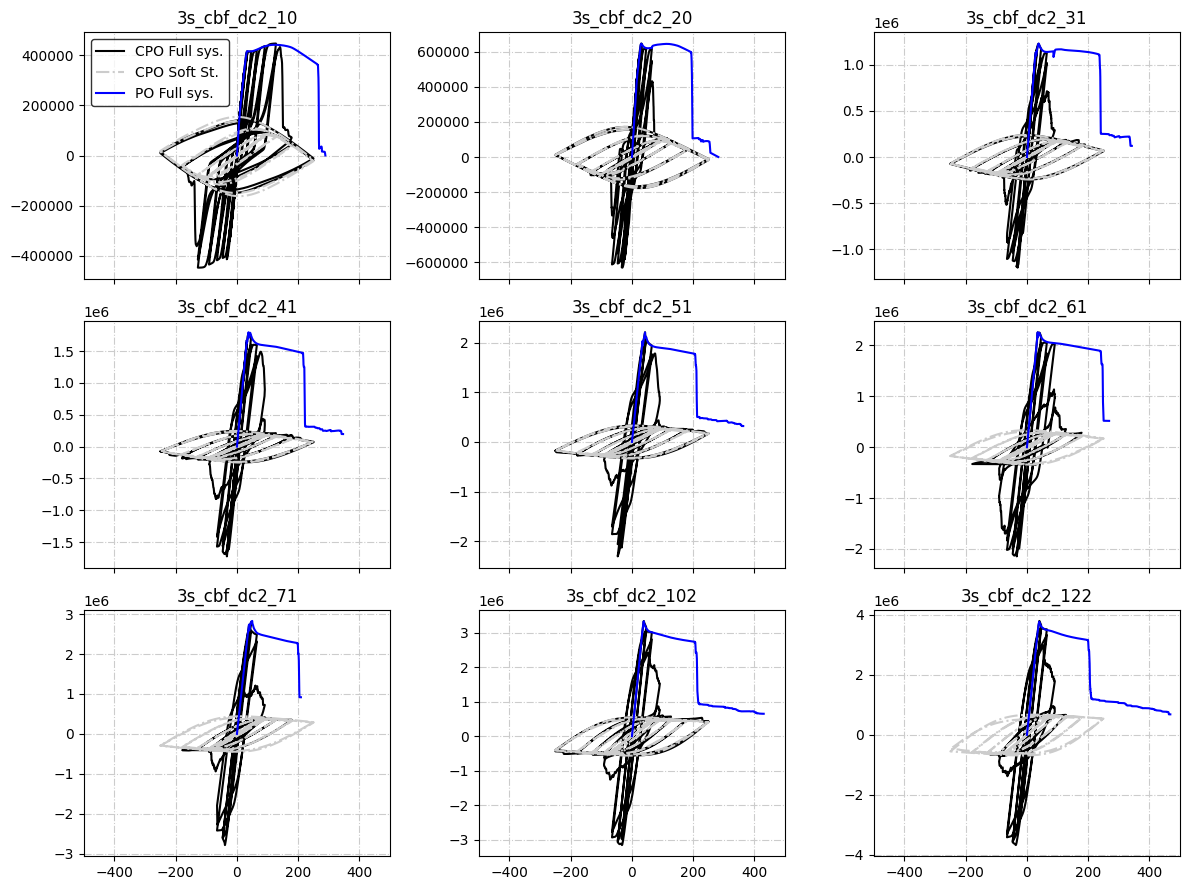

In [9]:
total_n = len(cpocs)
n_rows = int(np.ceil(total_n / 3))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

for (b, cpoc), ax in zip(cpocs.items(), axs.flatten()):
    
    poc = pocs[b]
    # poc_ss = pocs_ss[b]
    cpoc_ss = cpocs_ss[b]
    # bb_ss = eq_sdof_bbs_ss[b] * sdof_conv_data_ss[b]["gamma"]
    ax.plot(cpoc[:, 0], cpoc[:, 1], color="k", label="CPO Full sys.")
    ax.plot(cpoc_ss[:, 0], cpoc_ss[:, 1], color="0.8", ls="-.", label="CPO Soft St.")
    ax.plot(poc[:, 0], poc[:, 1], color="b", label="PO Full sys.")
    # ax.plot(poc_ss[:, 0], poc_ss[:, 1], color="r", label="PO Soft St.")
    # ax.plot(bb_ss[:, 0], bb_ss[:, 1], color="r", ls="--", label="BB Soft St.")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")
    
    print(b)
    print(f"    Full System : {cumulative_distance(cpoc[:, 0])[-1]:.2f} mm")
    print(f"    SS System   : {cumulative_distance(cpoc_ss[:, 0])[-1]:.2f} mm\n")

ax.set_xlim(-500, 500)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

The difference between the cyclic response of the full system and the soft storey system can be attributed to the braces

In [10]:
# harmonise the cyclic displacements
cpocs_br = {}

for b in buildings:
    cpoc_total, cpoc_ss, common_s = standardise_responses(cpocs[b], cpocs_ss[b])
    cpoc_brace = np.column_stack([cpoc_total[:, 0], cpoc_total[:, 1] - cpoc_ss[:, 1]])
    cpocs_br[b] = cpoc_brace

## 2.2 Load and compare 5 and 7 Storey Pushovers

In [11]:
pocs_57 = {}
pocs_57_ss = {}
cpocs_57 = {}
cpocs_57_ss = {}
eq_sdof_cpoc_57 = {}
eq_sdof_cpoc_57_ss = {}
gammas_57 = {}
m_stars_57 = {}
gammas_57_ss = {}
for b in bdata_df.index:
    if bdata_df.loc[b, "n_storeys"] in [5,7]:
        
        pocs_57[b] = _load_pushover_curve(ROOT / b)
        # pocs_57_ss[b] = _load_pushover_curve(ROOT / f"{b}_ss")
        cpocs_57[b] = _load_cyclic_pushover_curve(ROOT / b)
        cpocs_57_ss[b] = _load_cyclic_pushover_curve(ROOT / f"{b}_ss")

        eq_sdof_cpoc_57[b], gammas_57[b], m_stars_57[b], *_ = convert_poc_to_eq_sdof_poc(ROOT / b / "modal", cpocs_57[b])


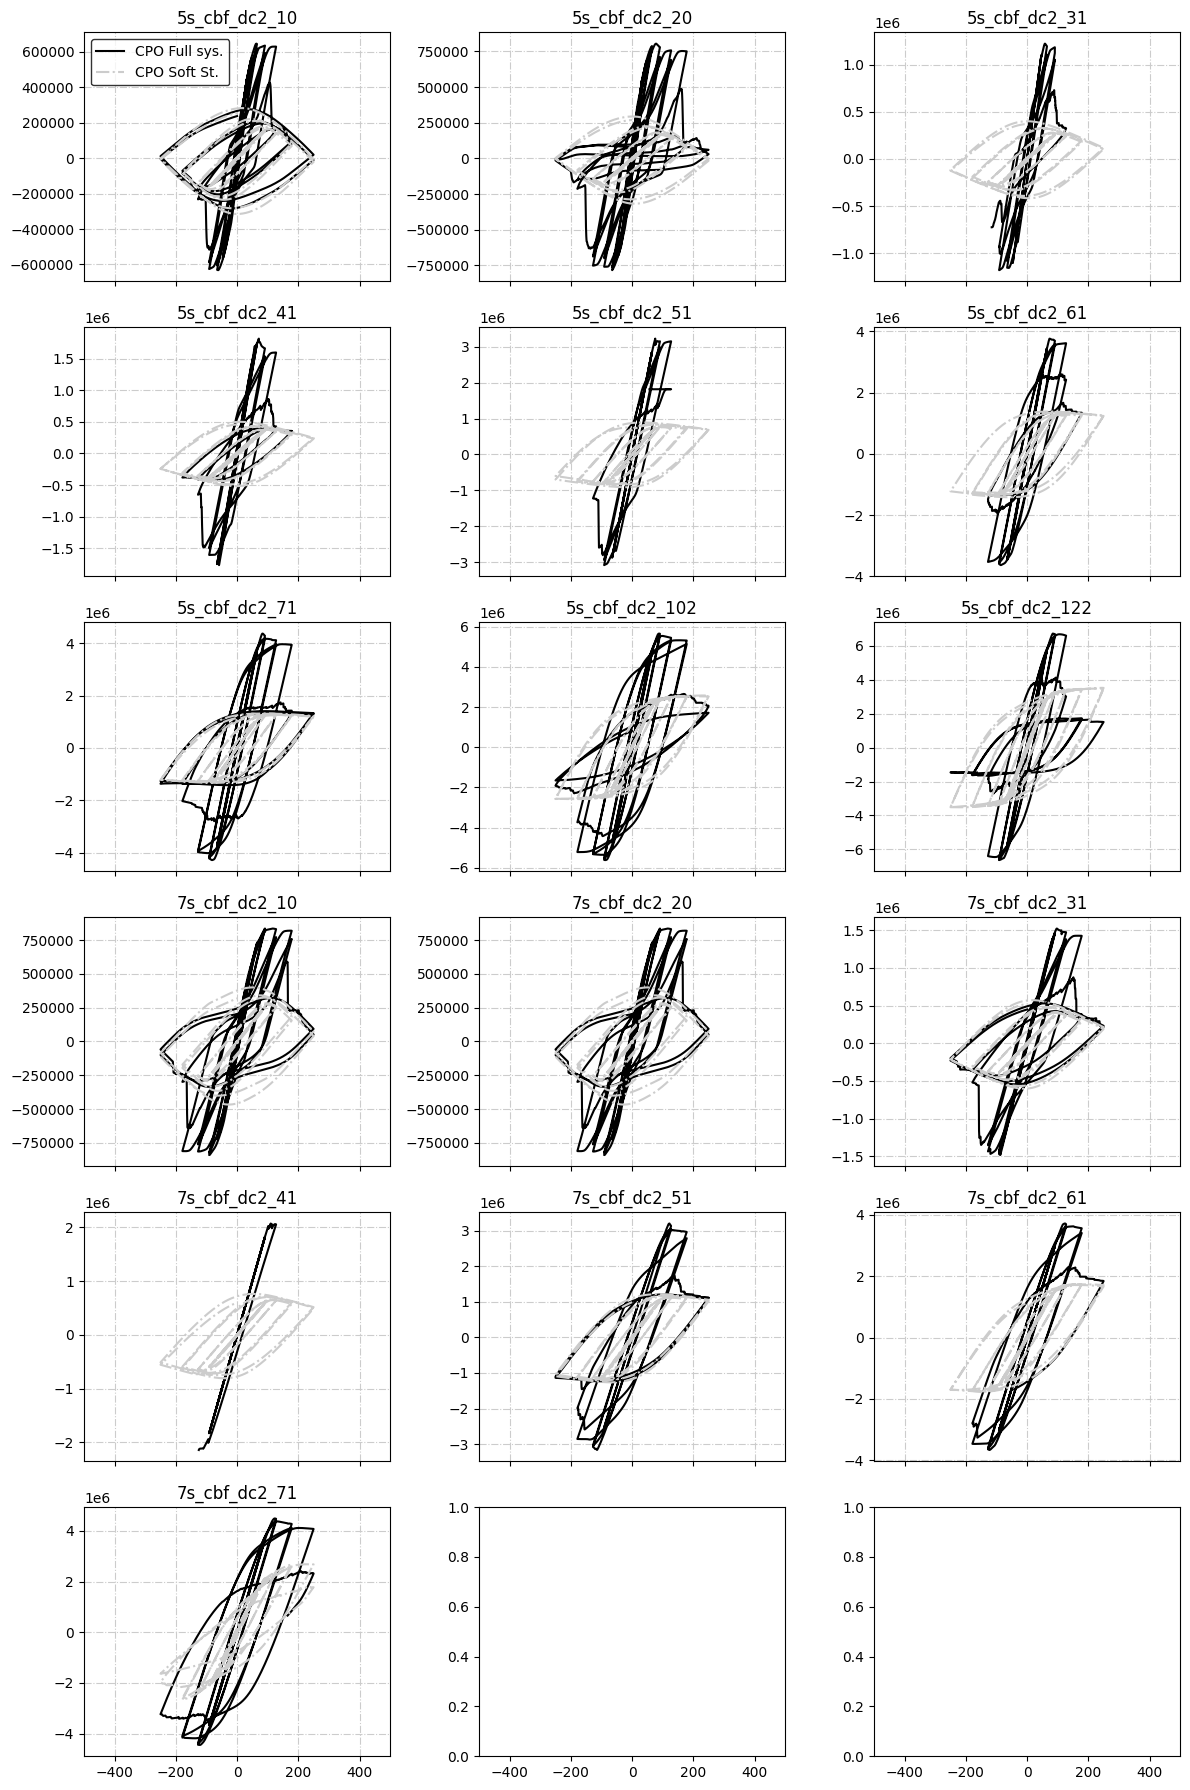

In [12]:
total_n = len(cpocs_57)
n_rows = int(np.ceil(total_n / 3))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

for (b, cpoc), ax in zip(cpocs_57.items(), axs.flatten()):
    
    poc = pocs_57[b]
    # poc_ss = pocs_ss[b]
    cpoc_ss = cpocs_57_ss[b]
    # bb_ss = eq_sdof_bbs_ss[b] * sdof_conv_data_ss[b]["gamma"]
    ax.plot(cpoc[:, 0], cpoc[:, 1], color="k", label="CPO Full sys.")
    ax.plot(cpoc_ss[:, 0], cpoc_ss[:, 1], color="0.8", ls="-.", label="CPO Soft St.")
    # ax.plot(poc[:, 0], poc[:, 1], color="b", label="PO Full sys.")
    # ax.plot(poc_ss[:, 0], poc_ss[:, 1], color="r", label="PO Soft St.")
    # ax.plot(bb_ss[:, 0], bb_ss[:, 1], color="r", ls="--", label="BB Soft St.")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")
    
    # print(b)
    # print(f"    Full System : {cumulative_distance(cpoc[:, 0])[-1]:.2f} mm")
    # print(f"    SS System   : {cumulative_distance(cpoc_ss[:, 0])[-1]:.2f} mm\n")

ax.set_xlim(-500, 500)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

## 2.3 Simplified Frame Backbone - 3S Structures

3s_cbf_dc2_10 : fy = 9.187e+04, ke = 8.71e+02, kh = -7.51e+02, b = -0.86, d_u = 122.26, mu_u = 2.16
3s_cbf_dc2_20 : fy = 9.767e+04, ke = 9.75e+02, kh = -7.28e+02, b = -0.75, d_u = 134.22, mu_u = 2.34
3s_cbf_dc2_31 : fy = 1.694e+05, ke = 1.80e+03, kh = -6.20e+02, b = -0.35, d_u = 273.04, mu_u = 3.90
3s_cbf_dc2_41 : fy = 1.740e+05, ke = 1.91e+03, kh = -6.20e+02, b = -0.32, d_u = 280.69, mu_u = 4.08
3s_cbf_dc2_51 : fy = 2.590e+05, ke = 2.95e+03, kh = -5.21e+02, b = -0.18, d_u = 497.04, mu_u = 6.67
3s_cbf_dc2_61 : fy = 2.644e+05, ke = 3.14e+03, kh = -5.41e+02, b = -0.17, d_u = 488.82, mu_u = 6.80
3s_cbf_dc2_71 : fy = 3.654e+05, ke = 4.52e+03, kh = -4.22e+02, b = -0.09, d_u = 866.49, mu_u = 11.73
3s_cbf_dc2_102 : fy = 4.742e+05, ke = 6.40e+03, kh = -3.59e+02, b = -0.06, d_u = 1319.94, mu_u = 18.81
3s_cbf_dc2_122 : fy = 5.982e+05, ke = 8.31e+03, kh = -3.09e+02, b = -0.04, d_u = 1937.30, mu_u = 27.91


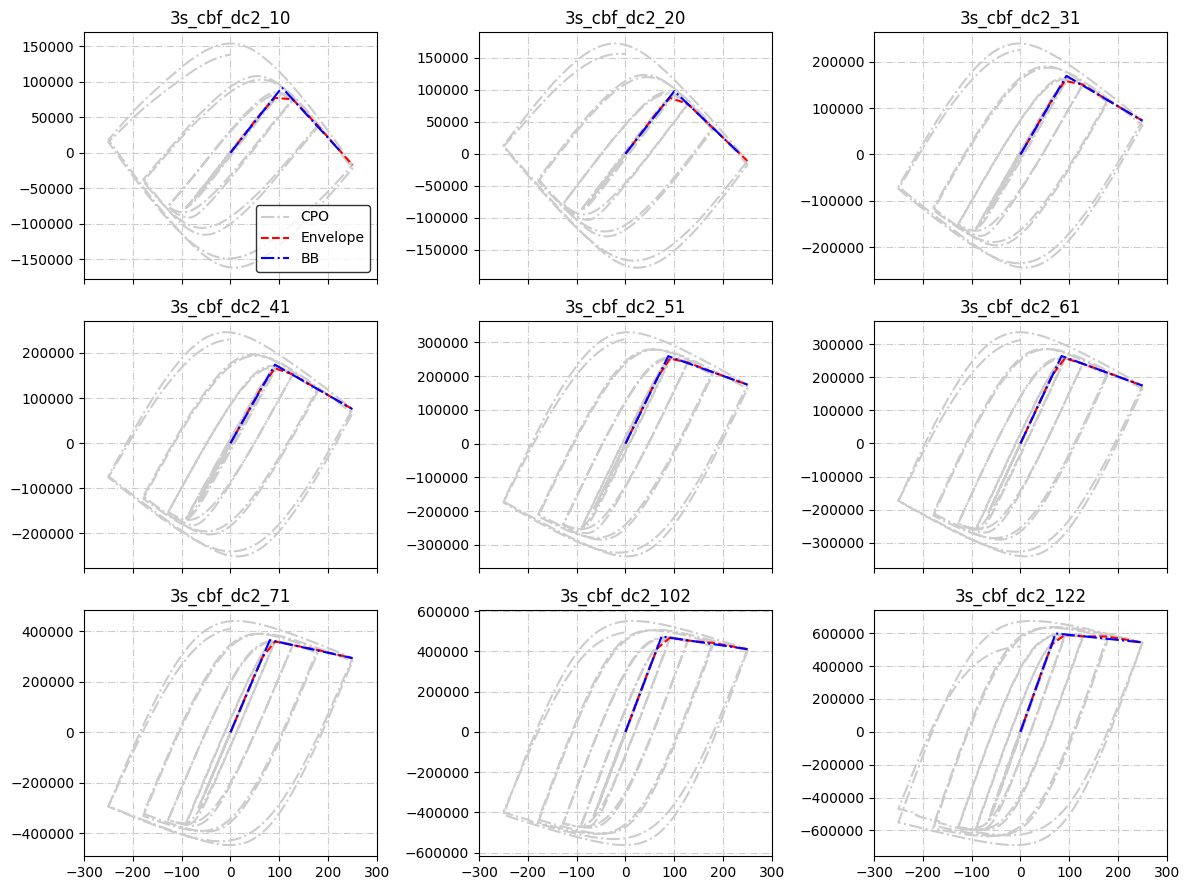

In [13]:
# Simplified backbones for the frame contribution
total_n = len(buildings)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

envelopes_ss = {}
bb_envs_ss = {}
bb_params_ss = {}

for b, ax in zip(buildings, axs.flatten()):
    envelope_ss, _ = fit_envelope(cpocs_ss[b]) 
    envelopes_ss[b] = envelope_ss

    bb_env_ss = fit_piecewise_backbone(envelope_ss, mode="bilinear_incl_neg_stiffness")
    ke = bb_env_ss[1, 1] / bb_env_ss[1, 0]
    kh = (bb_env_ss[2, 1] - bb_env_ss[1, 1]) / (bb_env_ss[2, 0] - bb_env_ss[1, 0])
    kh_ke = kh / ke
    dy = bb_env_ss[1, 1] / ke
    du = abs(bb_env_ss[1, 1] / kh)
    mu_ult = (du + dy) / dy

    bb_envs_ss[b] = bb_env_ss

    print(f"{b} : fy = {bb_env_ss[1, 1]:.3e}, ke = {ke:.2e}, kh = {kh:.2e}, b = {kh_ke:.2f}, d_u = {du:.2f}, mu_u = {mu_ult:.2f}")
    
    bb_params_ss[b] = {
        "Fy": bb_env_ss[1, 1],
        "E0": ke,
        "b": kh_ke,
        "du": du,
    }

    # poc_ss = pocs_ss[b]
    cpoc_ss = cpocs_ss[b]
    ax.plot(cpoc_ss[:, 0], cpoc_ss[:, 1], color="0.8", ls="-.", label="CPO")
    # ax.plot(poc_ss[:, 0], poc_ss[:, 1], color="r", label="PO SS")
    ax.plot(envelope_ss[:, 0], envelope_ss[:, 1], color="r", ls="--", label="Envelope")
    ax.plot(bb_env_ss[:, 0], bb_env_ss[:, 1], color="b", ls="-.", label="BB")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")

ax.set_xlim(-300, 300)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

bb_params_ss_df = pd.DataFrame(bb_params_ss).T

### 2.3.1 Parameterisation of spring backbone

In [14]:
def linear_model(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * (x**2) + b * x + c

def exponential_shifted(x, a, b, c):
    return a * np.exp(b * x) + c

def linear_constant_model(x, x_knot, m1, c1):
    """Initial linear drop that becomes perfectly constant after x_knot."""
    y_knot = m1 * x_knot + c1
    if isinstance(x, float) or isinstance(x, int):
        return float(np.where(x < x_knot, m1 * x + c1, y_knot))
    else:
        return np.where(x < x_knot, m1 * x + c1, y_knot)

def bilinear_piecewise_model(x, x_knot, m1, c1, m2):
    """Initial linear drop that becomes a different linear slope after x_knot."""
    y_knot = m1 * x_knot + c1
    if isinstance(x, float) or isinstance(x, int):
        return float(np.where(x < x_knot, m1 * x + c1, m2 * (x - x_knot) + y_knot))
    else:
        return np.where(x < x_knot, m1 * x + c1, m2 * (x - x_knot) + y_knot)
    
def calculate_fit_metrics(y_data, y_pred, num_params):
    n = len(y_data)
    
    # Residual Sum of Squares
    rss = np.sum((y_data - y_pred) ** 2)

    # Total Sum of Squares
    tss = np.sum((y_data - np.mean(y_data)) ** 2)

    # R-squared
    r2 = 1 - (rss / tss)

    # Adjusted R-squared
    r2_adj = 1 - ((1 - r2) * (n - 1) / (n - num_params - 1))

    # AIC (Akaike Information Criterion)
    # Constant terms are omitted as we only care about relative differences
    aic = 2 * num_params + n * np.log(rss / n)

    metric_tags = ["RSS", "R²", "R²_adj", "AIC"]
    metrics = pd.Series(dict(zip(metric_tags, (rss, r2, r2_adj, aic))))
    return metrics

In [15]:
bdata_df["Vb_coeff"] = bdata_df["design_baseshear"] / (bdata_df["seismic_mass"] * 9.81)
x_plot = np.linspace(0, 0.7)
storey_height = 3500
bay_width = 7000
aspect = storey_height / bay_width

#### Model for Fy

The yield point of the columns is normalised by the design base shear

Lincon Fit Coefficients:
x_knot = 0.0853
m = -12.4245
c = 1.3411

Bilinear Fit Coefficients:
x_knot = 0.0867
m1 = -12.4245
c1 = 1.3411
m2 = 0.0578

                      RSS        R²    R²_adj        AIC
Linear Constant  0.008053  0.979955  0.967928 -57.170641
Bilinear         0.007556  0.981192  0.962385 -55.744153


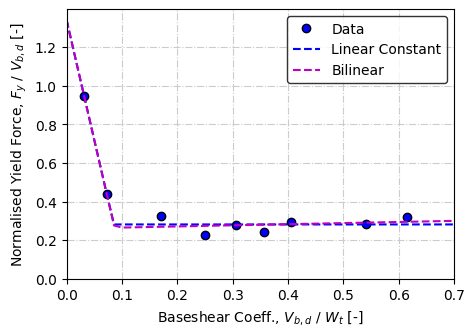

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

Fy_norm = bb_params_ss_df.loc[buildings, "Fy"] / bdata_df.loc[buildings, "design_baseshear"]
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], Fy_norm,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Piecewise Linear - This is appropriate because there is a physical change 
# between the second and third point. Points 1 and 2 are governed by gravity design, 
# while after point 3 the column strength is governed by seismic design.
initial_guess = [0.1, -12.0, 1.2]
Fy_col_lincon_popt, _ = curve_fit(
linear_constant_model, bdata_df.loc[buildings, "Vb_coeff"], Fy_norm, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *Fy_col_lincon_popt)
ax.plot(x_plot, y_plot, color="b", ls="--", label="Linear Constant")

y_pred = linear_constant_model(bdata_df.loc[buildings, "Vb_coeff"], *Fy_col_lincon_popt)
Fy_col_lincon_fit_metrics = calculate_fit_metrics(Fy_norm, y_pred, num_params=len(Fy_col_lincon_popt))

# Bilinear
initial_guess = [0.1, -12.0, 1.2, -1.0]
Fy_col_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, bdata_df.loc[buildings, "Vb_coeff"], Fy_norm, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *Fy_col_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear")

y_bilin_pred = bilinear_piecewise_model(bdata_df.loc[buildings, "Vb_coeff"], *Fy_col_bilin_popt)
Fy_col_bilin_fit_metrics = calculate_fit_metrics(Fy_norm, y_bilin_pred, num_params=len(Fy_col_bilin_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Normalised Yield Force, $F_y$ / $V_{b,d}$ [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Lincon Fit Coefficients:\nx_knot = {Fy_col_lincon_popt[0]:.4f}\nm = {Fy_col_lincon_popt[1]:.4f}\nc = {Fy_col_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficients:\nx_knot = {Fy_col_bilin_popt[0]:.4f}\nm1 = {Fy_col_bilin_popt[1]:.4f}\nc1 = {Fy_col_bilin_popt[2]:.4f}\nm2 = {Fy_col_bilin_popt[3]:.4f}\n")

print(pd.DataFrame([Fy_col_lincon_fit_metrics, Fy_col_bilin_fit_metrics], index=["Linear Constant", "Bilinear"]))

In [17]:
bdata_df["Vb_coeff"]

name
3s_cbf_dc2_10     0.031657
3s_cbf_dc2_20     0.072553
3s_cbf_dc2_31     0.169777
3s_cbf_dc2_41     0.250735
3s_cbf_dc2_51     0.305320
3s_cbf_dc2_61     0.357053
3s_cbf_dc2_71     0.406120
3s_cbf_dc2_102    0.541280
3s_cbf_dc2_122    0.614880
5s_cbf_dc2_10     0.031682
5s_cbf_dc2_20     0.045689
5s_cbf_dc2_31     0.103241
5s_cbf_dc2_41     0.149382
5s_cbf_dc2_51     0.288368
5s_cbf_dc2_61     0.357053
5s_cbf_dc2_71     0.406120
5s_cbf_dc2_102    0.541280
5s_cbf_dc2_122    0.614880
7s_cbf_dc2_10     0.034169
7s_cbf_dc2_20     0.035936
7s_cbf_dc2_31     0.089107
7s_cbf_dc2_41     0.125839
7s_cbf_dc2_51     0.197267
7s_cbf_dc2_61     0.249122
7s_cbf_dc2_71     0.314113
Name: Vb_coeff, dtype: float64

#### Model for E0

The stiffness is made dimensionless by dividing by using the yield strength and the storey height to normalise it

Linear Fit Coefficients:
m = -0.0161
c = 0.0300

Fit Metrics:
RSS       9.729649e-07
R²        9.882459e-01
R²_adj    9.843279e-01
AIC      -1.403613e+02
dtype: float64


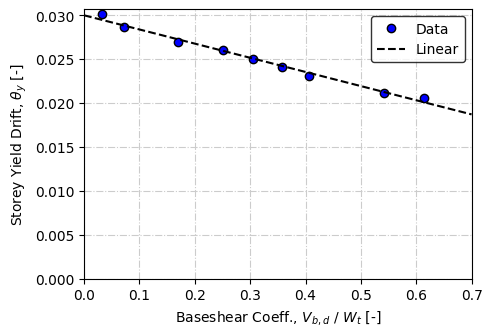

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

# brace_alpha = np.arctan(storey_height / bay_width)
# normalisation_factor_vb = bdata_df.loc[buildings, "design_baseshear"] * np.sin(brace_alpha) * np.cos(brace_alpha) ** 2 / storey_height
# thetay = bb_params_ss_df.loc[buildings, "E0"] / normalisation_factor_vb

thetay = bb_params_ss_df.loc[buildings, "Fy"] / bb_params_ss_df.loc[buildings, "E0"] / storey_height


ax.plot(bdata_df.loc[buildings, "Vb_coeff"], thetay,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Linear
initial_guess = [0.013, -0.03]
thetay_popt, _ = curve_fit(
linear_model, bdata_df.loc[buildings, "Vb_coeff"], thetay, 
p0=initial_guess)
y_plot = linear_model(x_plot, *thetay_popt)
ax.plot(x_plot, y_plot, color="k", ls="--", label="Linear")

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Storey Yield Drift, $\theta_y$ [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

y_pred = linear_model(bdata_df.loc[buildings, "Vb_coeff"], *thetay_popt)
thetay_fit_metrics = calculate_fit_metrics(thetay, y_pred, num_params=len(thetay_popt))

print(f"Linear Fit Coefficients:\nm = {thetay_popt[0]:.4f}\nc = {thetay_popt[1]:.4f}\n")
print("Fit Metrics:")
print(thetay_fit_metrics)

#### Model for Post-Yield Slope, b

Quadratic Fit Coefficients:
a = -3.2971
b = 3.4698
c = -0.9496

Exponential Fit Coefficients:
a = -1.0444
b = -5.5025
c = -0.0023

Bilinear Fit Coefficients:
x_knot = 0.1836
m1 = 3.8141
c1 = -0.9995
m2 = 0.6805

                  RSS        R²    R²_adj        AIC
Quadratic    0.018210  0.974685  0.959497 -49.827270
Exponential  0.011706  0.983726  0.973962 -53.803747
Bilinear     0.011560  0.983929  0.967858 -51.916533


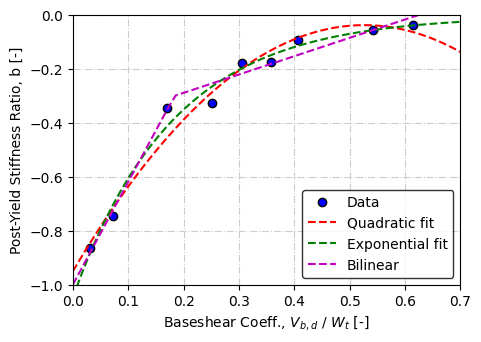

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

b_data = bb_params_ss_df.loc[buildings, "b"]
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], b_data,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# quadratic fit
initial_guess = [0, 1.0, min(b_data) * 1.1]
b_col_quad_popt, _ = curve_fit(
quadratic, bdata_df.loc[buildings, "Vb_coeff"], b_data, p0=initial_guess
)
y_quad = quadratic(x_plot, *b_col_quad_popt)
ax.plot(x_plot, y_quad, color="r", ls="--", label="Quadratic fit")

y_pred_quad = quadratic(bdata_df.loc[buildings, "Vb_coeff"], *b_col_quad_popt)
b_col_quad_fit_metrics = calculate_fit_metrics(b_data, y_pred_quad, num_params=len(b_col_quad_popt))

# exponential fit
initial_guess = [-2, -1.0, min(b_data) * 1.1]
b_col_exp_popt, _ = curve_fit(
exponential_shifted, bdata_df.loc[buildings, "Vb_coeff"], b_data, p0=initial_guess
)
y_exp = exponential_shifted(x_plot, *b_col_exp_popt)
ax.plot(x_plot, y_exp, color="g", ls="--", label="Exponential fit")

y_pred_exp = exponential_shifted(bdata_df.loc[buildings, "Vb_coeff"], *b_col_exp_popt)
b_col_exp_fit_metrics = calculate_fit_metrics(b_data, y_pred_exp, num_params=len(b_col_exp_popt))

# Bilinear
initial_guess = [0.1, -12.0, 1.2, -1.0]
b_col_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, bdata_df.loc[buildings, "Vb_coeff"], b_data, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *b_col_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear")

y_pred_bilin = bilinear_piecewise_model(bdata_df.loc[buildings, "Vb_coeff"], *b_col_bilin_popt)
b_col_bilin_fit_metrics = calculate_fit_metrics(b_data, y_pred_bilin, num_params=len(b_col_bilin_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Post-Yield Stiffness Ratio, b [-]")
ax.set_ylim(-1.0, 0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Quadratic Fit Coefficients:\na = {b_col_quad_popt[0]:.4f}\nb = {b_col_quad_popt[1]:.4f}\nc = {b_col_quad_popt[2]:.4f}\n")
print(f"Exponential Fit Coefficients:\na = {b_col_exp_popt[0]:.4f}\nb = {b_col_exp_popt[1]:.4f}\nc = {b_col_exp_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficients:\nx_knot = {b_col_bilin_popt[0]:.4f}\nm1 = {b_col_bilin_popt[1]:.4f}\nc1 = {b_col_bilin_popt[2]:.4f}\nm2 = {b_col_bilin_popt[3]:.4f}\n")

print(pd.DataFrame([b_col_quad_fit_metrics, b_col_exp_fit_metrics, b_col_bilin_fit_metrics], index=["Quadratic", "Exponential", "Bilinear"]))

#### Selected Equations

Fy - Linear constant  
E0 - Linear (storey yield drift)  
b  - Inverted exponential decay  
$\mu_{ult}$ - Exponential


In [20]:
def _Fy_col(Vb_coeff, Wt):
    x_knot = 0.0853
    m = -12.4245
    c = 1.3411
    return linear_constant_model(Vb_coeff, x_knot, m, c) * Vb_coeff * Wt

def _E0_col(Vb_coeff, Wt, hi):
    m = -0.0161
    c = 0.0300
    theta_y = linear_model(Vb_coeff, m, c) 
    fy = _Fy_col(Vb_coeff, Wt)
    return fy / theta_y / hi

def _b_col(Vb_coeff):
    a = -1.0444
    b = -5.5025
    c = -0.0023
    return exponential_shifted(Vb_coeff, a, b, c)
    
def get_approximate_ss_backbone_params(Vb_coeff, Wt, hi):
    Fy = _Fy_col(Vb_coeff, Wt)
    E0 = _E0_col(Vb_coeff, Wt, hi)
    b = _b_col(Vb_coeff)
    return Fy, E0, b


def get_approximate_ss_backbone(Vb_coeff, Wt, hi):
    """ returns the points of backbone curve for the soft storey system calculated
    using the fitted predictions equations for Fy, E0, b and mu_ult. """

    Fy, E0, b = get_approximate_ss_backbone_params(Vb_coeff, Wt, hi)
    
    dy = Fy / E0
    du = dy + Fy / (abs(b) * E0)
    
    p1 = [0, 0]
    p2 = [dy, Fy]
    p3 = [du, 0]

    return np.column_stack([p1, p2, p3]).T

#### Compare Predictions with the Originals

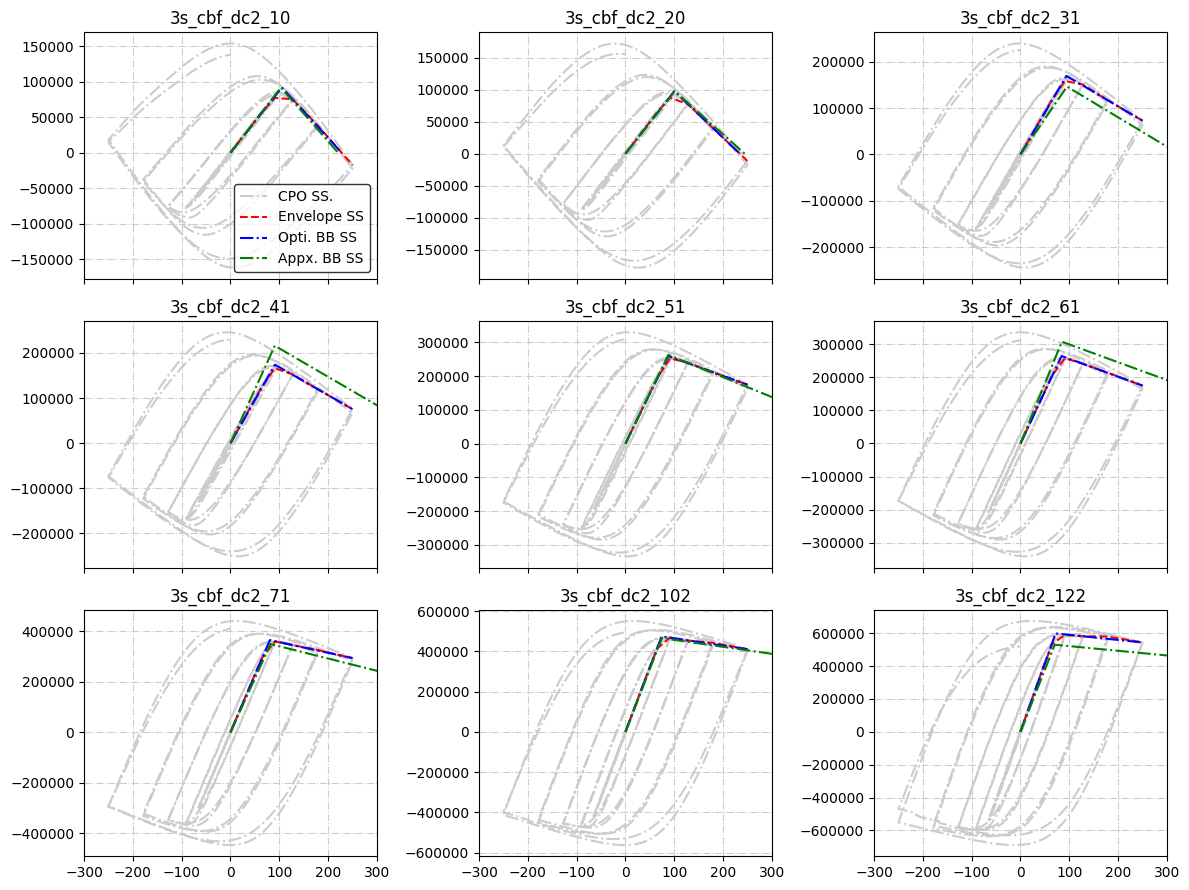

In [21]:
# Simplified backbones for the frame contribution
total_n = len(buildings)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

appx_bb_ss = {}
appx_bb_params_ss = {}

for b, ax in zip(buildings, axs.flatten()):
    
    vb_coeff = bdata_df.loc[b, "Vb_coeff"]
    Wt = bdata_df.loc[b, "seismic_mass"] * 9.81

    appx_bb_params = get_approximate_ss_backbone_params(vb_coeff, Wt, storey_height)
    appx_bb = get_approximate_ss_backbone(vb_coeff, Wt, storey_height)
    appx_bb_ss[b] = appx_bb
    bb_env_ss = bb_envs_ss[b]
    envelope_ss = envelopes_ss[b]

    appx_bb_params_ss[b] = {        # in sdof coordinates
        "Fy": appx_bb_params[0] / gammas[b],
        "E0": appx_bb_params[1],
        "b": appx_bb_params[2],
        "du": (appx_bb[2, 0] - appx_bb[1, 0]) / gammas[b],
        "mu_ult": appx_bb[2, 0] / appx_bb[1, 0]
    }

    cpoc_ss = cpocs_ss[b]
    ax.plot(cpoc_ss[:, 0], cpoc_ss[:, 1], color="0.8", ls="-.", label="CPO SS.")
    ax.plot(envelope_ss[:, 0], envelope_ss[:, 1], color="r", ls="--", label="Envelope SS")
    ax.plot(bb_env_ss[:, 0], bb_env_ss[:, 1], color="b", ls="-.", label="Opti. BB SS")
    ax.plot(appx_bb[:, 0], appx_bb[:, 1], color="g", ls="-.", label="Appx. BB SS")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")

ax.set_xlim(-300, 300)
# ax.set_ylim(-8e5, 8e5)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

bb_params_ss_df = pd.DataFrame(bb_params_ss).T

## 2.4 Simplified Brace Backbone - 3S Structures

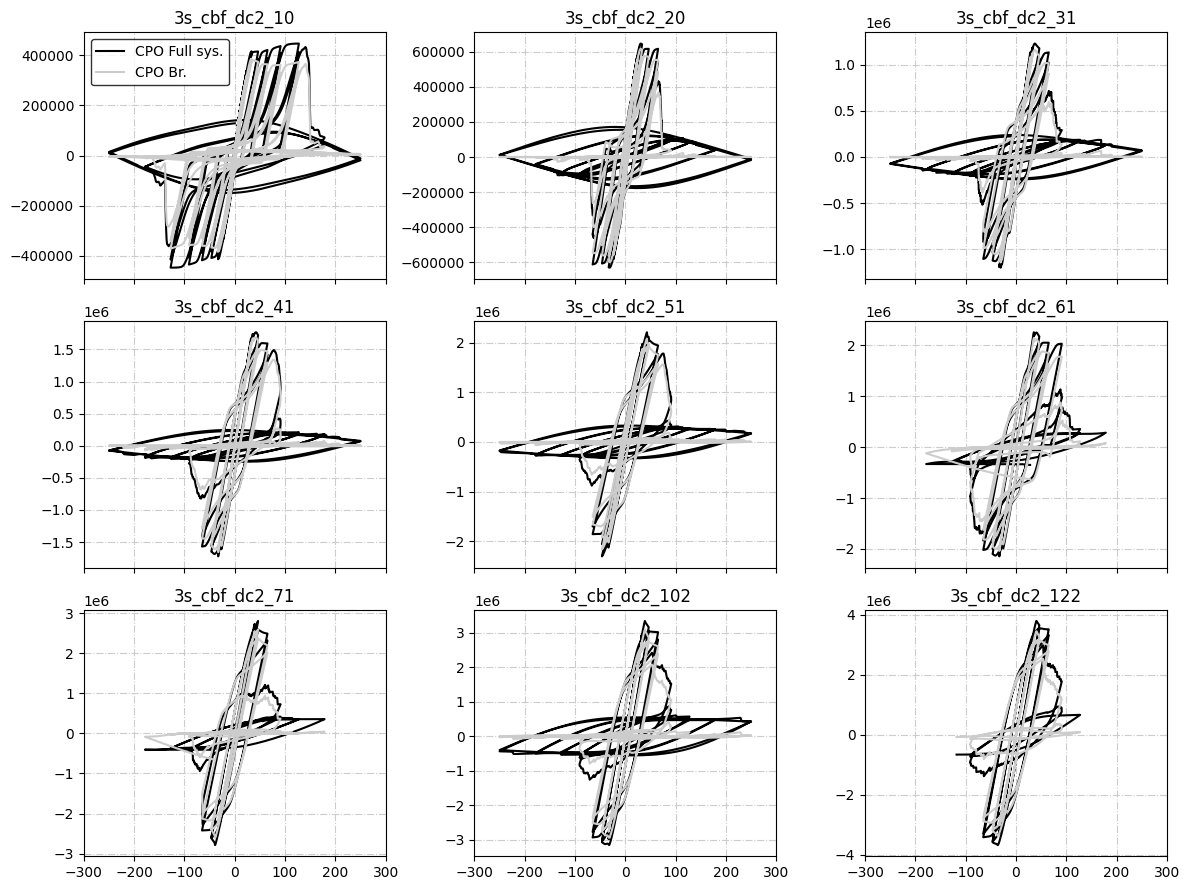

In [22]:
# plot the brace response
total_n = len(cpocs)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3 ), sharex=True)

for (b, cpoc), ax in zip(cpocs.items(), axs.flatten()):
    
    cpoc_br = cpocs_br[b]
    ax.plot(cpoc[:, 0], cpoc[:, 1], color="k", label="CPO Full sys.")
    ax.plot(cpoc_br[:, 0], cpoc_br[:, 1], color="0.8", ls="-", label="CPO Br.")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")
    
ax.set_xlim(-300, 300)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()


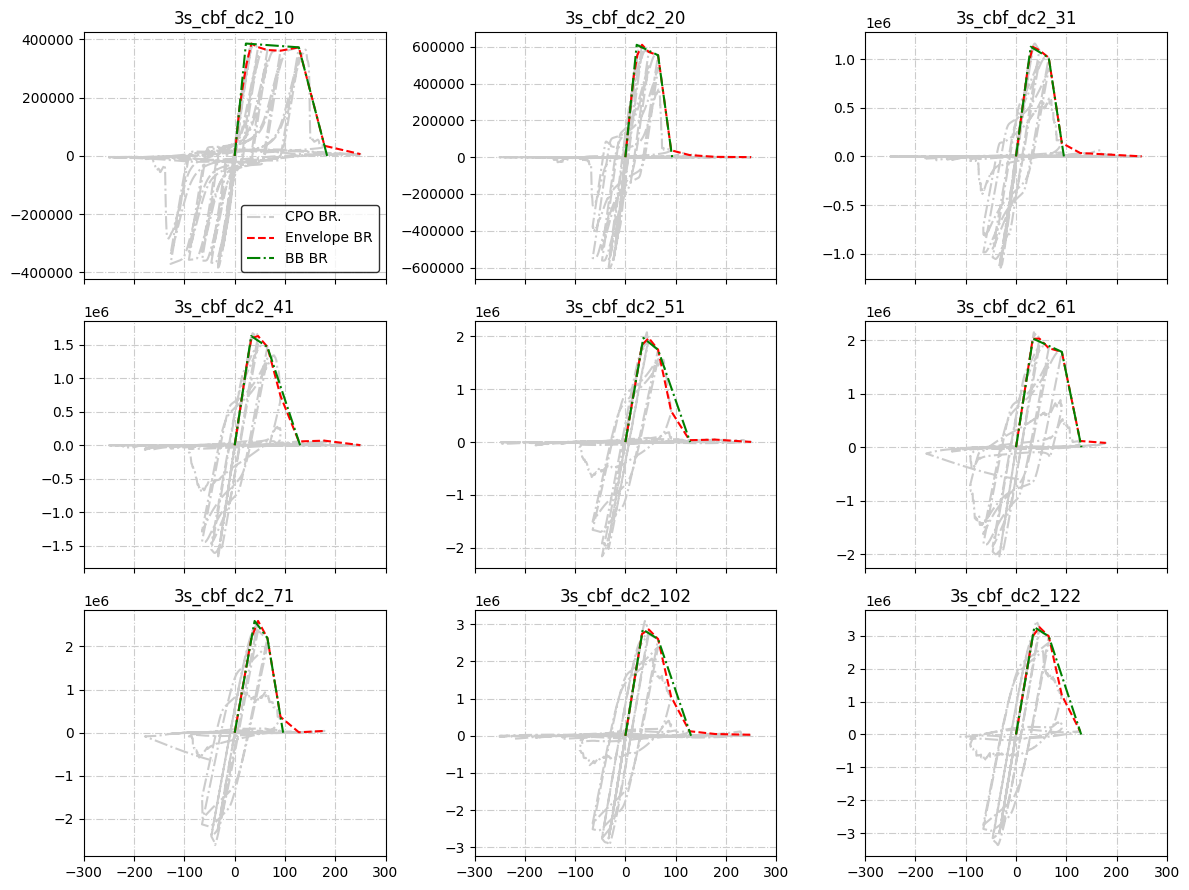

In [23]:
# Simplified backbones for the brace contribution
total_n = len(buildings)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

collapse_residual = True

envelopes_br = {}
bb_envs_br = {}
bb_params_br = {}
bb_params_br_2 = {}

param_tags_2 = ["Fy", "E0", "b", "mu_fr", "mu_r"]

for b, ax in zip(buildings, axs.flatten()):
    cpoc_br = cpocs_br[b]
    envelope_br, _ = fit_envelope(cpoc_br, ) 
    envelopes_br[b] = envelope_br

    bb_env_br = fit_tetralinear_backbone(
        envelope_br, residual_force_fraction=0.1, collapse_residual=collapse_residual)
    bb_envs_br[b] = bb_env_br

    if collapse_residual:
        bb_params_br[b] = np.concatenate([bb_env_br[1:-1, [1,0]], -bb_env_br[1:-1, [1,0]]]).flatten().tolist()
    else:
        bb_params_br[b] = np.concatenate([bb_env_br[1:, [1,0]], -bb_env_br[1:, [1,0]]]).flatten().tolist()

    ax.plot(cpoc_br[:, 0], cpoc_br[:, 1], color="0.8", ls="-.", label="CPO BR.")
    ax.plot(envelope_br[:, 0], envelope_br[:, 1], color="r", ls="--", label="Envelope BR")
    ax.plot(bb_env_br[:, 0], bb_env_br[:, 1], color="g", ls="-.", label="BB BR")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")

    fy = bb_env_br[1, 1]
    dy = bb_env_br[1, 0]
    E0 = bb_env_br[1, 1] / bb_env_br[1, 0]
    kh = (bb_env_br[2, 1] - bb_env_br[1, 1]) / (bb_env_br[2, 0] - bb_env_br[1, 0]) / E0
    mu_fr = bb_env_br[2, 0] / dy
    mu_r = bb_env_br[3, 0] / dy

    bb_params_br_2[b] = [fy, E0, kh, mu_fr, mu_r]
    
ax.set_xlim(-300, 300)
leg = axs.flatten()[0].legend(loc="lower right")
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

bb_params_br_df = pd.DataFrame(bb_params_br_2).T
bb_params_br_df.columns = param_tags_2

In [24]:
bb_params_br_df

,Fy,E0,b,mu_fr,mu_r
3s_cbf_dc2_10,3.856946e+05,17289.354731,-0.007162,5.717670,8.238753
3s_cbf_dc2_20,6.105432e+05,27070.032426,-0.049458,2.885359,4.123263
3s_cbf_dc2_31,1.125907e+06,38644.353414,-0.080932,2.233629,3.267480
3s_cbf_dc2_41,1.629928e+06,49779.841331,-0.100776,1.987525,3.972598
3s_cbf_dc2_51,1.969872e+06,55098.529956,-0.137476,1.820244,3.604478
3s_cbf_dc2_61,2.028262e+06,60235.168181,-0.071720,2.705718,3.863236
3s_cbf_dc2_71,2.590870e+06,65432.352154,-0.238104,1.643518,2.432924
3s_cbf_dc2_102,2.861307e+06,82591.874809,-0.102890,1.878453,3.770717
3s_cbf_dc2_122,3.264276e+06,89677.478089,-0.107914,1.787821,3.559926


### 2.4.1 Parameterisation of spring backbone

#### Model for Fy

Lincon Fit Coefficients:
x_knot = 0.0984
m = -30.0954
c = 4.9319

Bilinear Fit Coefficients:
x_knot = 0.0674
m1 = -41.2913
c1 = 5.2864
m2 = -1.5976

                      RSS        R²    R²_adj        AIC
Linear Constant  0.221767  0.944527  0.911243 -27.330172
Bilinear         0.162792  0.959279  0.918558 -28.112555


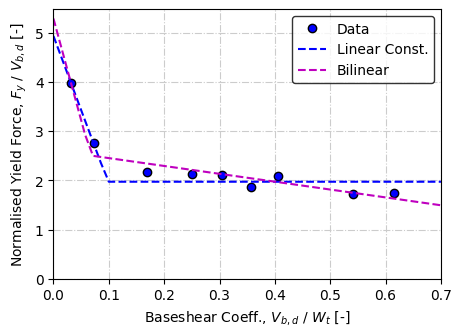

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

Fy_norm = bb_params_br_df.loc[buildings, "Fy"] / bdata_df.loc[buildings, "design_baseshear"]
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], Fy_norm,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Piecewise Linear Constant
initial_guess = [0.1, -12.0, 1.2]
Fy_lincon_popt, _ = curve_fit(
linear_constant_model, bdata_df.loc[buildings, "Vb_coeff"], Fy_norm, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *Fy_lincon_popt)
ax.plot(x_plot, y_plot, color="b", ls="--", label="Linear Const.")

y_lincon_pred = linear_constant_model(bdata_df.loc[buildings, "Vb_coeff"], *Fy_lincon_popt)
Fy_lincon_fit_metrics = calculate_fit_metrics(Fy_norm, y_lincon_pred, num_params=len(Fy_lincon_popt))

# Piecewise Bilinear
initial_guess = [0.1, -12.0, 1.2, -1.0]
Fy_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, bdata_df.loc[buildings, "Vb_coeff"], Fy_norm, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *Fy_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear")

y_bilin_pred = bilinear_piecewise_model(bdata_df.loc[buildings, "Vb_coeff"], *Fy_bilin_popt)
Fy_bilin_fit_metrics = calculate_fit_metrics(Fy_norm, y_bilin_pred, num_params=len(Fy_bilin_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Normalised Yield Force, $F_y$ / $V_{b,d}$ [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Lincon Fit Coefficients:\nx_knot = {Fy_lincon_popt[0]:.4f}\nm = {Fy_lincon_popt[1]:.4f}\nc = {Fy_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficients:\nx_knot = {Fy_bilin_popt[0]:.4f}\nm1 = {Fy_bilin_popt[1]:.4f}\nc1 = {Fy_bilin_popt[2]:.4f}\nm2 = {Fy_bilin_popt[3]:.4f}\n")

print(pd.DataFrame([Fy_lincon_fit_metrics, Fy_bilin_fit_metrics], index=["Linear Constant", "Bilinear"]))

#### Model for E0

Exponential Fit Coefficients:
a = 1810.2138
b = -12.5761
c = 508.4157

Lincon Fit Coefficients:
x_knot = 0.1190
m = -13519.1487
c = 2172.9726

Bilinear Fit Coefficients:
x_knot = 0.1083
m1 = -13519.1487
c1 = 2172.9726
m2 = -540.3624

Fit Metrics:
                          RSS        R²    R²_adj        AIC
Exponential       8061.695860  0.994541  0.991266  67.178892
Linear Constant  50260.890208  0.965968  0.945549  83.649822
Bilinear          6801.640788  0.995395  0.990789  67.649251


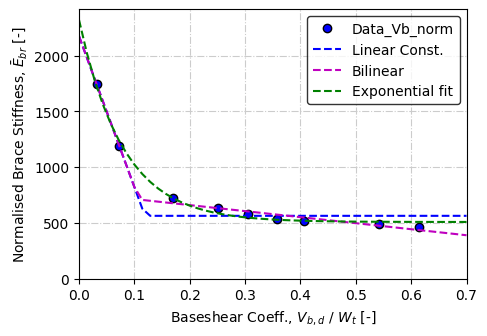

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 
brace_alpha = np.arctan(storey_height / bay_width)

# normalisation_factor_fy = bb_params_br_df.loc[buildings, "Fy"] * np.sin(brace_alpha) * np.cos(brace_alpha) ** 2 / storey_height
# E0_norm_fy = bb_params_br_df.loc[buildings, "E0"] / normalisation_factor_fy
# ax.plot(bdata_df.loc[buildings, "Vb_coeff"], E0_norm_fy,
#         marker="o", ls="", mfc="m", mec="k", label="Data_Fy_normed" )

normalisation_factor_vb = bdata_df.loc[buildings, "design_baseshear"] * np.sin(brace_alpha) * np.cos(brace_alpha) ** 2 / storey_height
E0_norm_Vb = bb_params_br_df.loc[buildings, "E0"] / normalisation_factor_vb

ax.plot(bdata_df.loc[buildings, "Vb_coeff"], E0_norm_Vb,
        marker="o", ls="", mfc="b", mec="k", label="Data_Vb_norm" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Piecewise Linear Constant
initial_guess = [0.1, -12000, 2000]
E0_norm_Vb_lincon_popt, _ = curve_fit(
linear_constant_model, bdata_df.loc[buildings, "Vb_coeff"], E0_norm_Vb, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *E0_norm_Vb_lincon_popt)
ax.plot(x_plot, y_plot, color="b", ls="--", label="Linear Const.")

y_lincon_pred = linear_constant_model(bdata_df.loc[buildings, "Vb_coeff"], *E0_norm_Vb_lincon_popt)
E0_norm_Vb_lincon_fit_metrics = calculate_fit_metrics(E0_norm_Vb, y_lincon_pred, num_params=len(E0_norm_Vb_lincon_popt))

# Piecewise Bilinear
initial_guess = [0.1, -12000, 2000, -1000.0]
E0_norm_Vb_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, bdata_df.loc[buildings, "Vb_coeff"], E0_norm_Vb, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *E0_norm_Vb_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear")

y_bilin_pred = bilinear_piecewise_model(bdata_df.loc[buildings, "Vb_coeff"], *E0_norm_Vb_bilin_popt)
E0_norm_Vb_bilin_fit_metrics = calculate_fit_metrics(E0_norm_Vb, y_bilin_pred, num_params=len(E0_norm_Vb_bilin_popt))

# exponential fit
initial_guess = [100, 1.0, min(E0_norm_Vb) * 1.1]
E0_exp_popt, _ = curve_fit(
exponential_shifted, bdata_df.loc[buildings, "Vb_coeff"], E0_norm_Vb, p0=initial_guess
)
y_exp = exponential_shifted(x_plot, *E0_exp_popt)
ax.plot(x_plot, y_exp, color="g", ls="--", label="Exponential fit")

y_pred_exp = exponential_shifted(bdata_df.loc[buildings, "Vb_coeff"], *E0_exp_popt)
E0_exp_fit_metrics = calculate_fit_metrics(E0_norm_Vb, y_pred_exp, num_params=len(E0_exp_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Normalised Brace Stiffness, $\bar{E}_{br}$ [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Exponential Fit Coefficients:\na = {E0_exp_popt[0]:.4f}\nb = {E0_exp_popt[1]:.4f}\nc = {E0_exp_popt[2]:.4f}\n")
print(f"Lincon Fit Coefficients:\nx_knot = {E0_norm_Vb_lincon_popt[0]:.4f}\nm = {E0_norm_Vb_lincon_popt[1]:.4f}\nc = {E0_norm_Vb_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficients:\nx_knot = {E0_norm_Vb_bilin_popt[0]:.4f}\nm1 = {E0_norm_Vb_bilin_popt[1]:.4f}\nc1 = {E0_norm_Vb_bilin_popt[2]:.4f}\nm2 = {E0_norm_Vb_bilin_popt[3]:.4f}\n")

print("Fit Metrics:")
print(pd.DataFrame([E0_exp_fit_metrics, E0_norm_Vb_lincon_fit_metrics, E0_norm_Vb_bilin_fit_metrics], index=["Exponential", "Linear Constant", "Bilinear"]))

#### Model for Post-Yield Slope, b

Linear Constant Fit Coefficients wo Outlier:
x_knot = 0.1217
m = -1.0342
c = 0.0256

Linear Constant Fit Coefficients w Outlier:
x_knot = 0.1407
m = -1.0342
c = 0.0256

Bilinear Fit Coefficients wo Outlier:
x_knot = 0.1148
m1 = -1.0342
c1 = 0.0256
m2 = -0.0277

Bilinear Fit Coefficients w Outlier:
x_knot = 0.1278
m1 = -1.0342
c1 = 0.0256
m2 = -0.0537

Fit Metrics:
                                 RSS        R²    R²_adj        AIC
Linear Constant wo Outlier  0.002639  0.766552  0.591467 -58.134842
Linear Constant w Outlier   0.018920  0.424657  0.079451 -49.483064
Bilinear wo Outlier         0.002525  0.776582  0.478691 -56.486141
Bilinear w Outlier          0.018491  0.437690 -0.124619 -47.689286


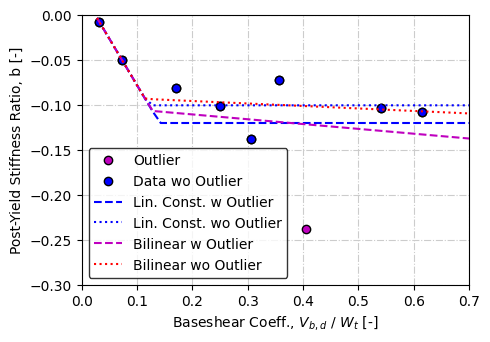

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

b_data = bb_params_br_df.loc[buildings, "b"]
b_data2 = bb_params_br_df.loc[buildings, "b"].values.tolist()
b_data2.pop(6)
Vb_coeff2 = bdata_df.loc[buildings, "Vb_coeff"].values.tolist()
Vb_coeff2.pop(6)
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], b_data,
        marker="o", ls="", mfc="m", mec="k", label="Outlier" )
ax.plot(Vb_coeff2, b_data2,
        marker="o", ls="", mfc="b", mec="k", label="Data wo Outlier" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Piecewise Linear Constant w Outlier
initial_guess = [0.1, -12.0, 1.2]
b_lincon_popt, _ = curve_fit(
linear_constant_model, bdata_df.loc[buildings, "Vb_coeff"], b_data, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *b_lincon_popt)
ax.plot(x_plot, y_plot, color="b", ls="--", label="Lin. Const. w Outlier")

# Piecewise Linear Constant wo Outlier
initial_guess = [0.1, -12.0, 1.2]
b_lincon_popt_woo, _ = curve_fit(
linear_constant_model, Vb_coeff2, b_data2, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *b_lincon_popt_woo)
ax.plot(x_plot, y_plot, color="b", ls=":", label="Lin. Const. wo Outlier")

# Piecewise Bilinear w Outlier
initial_guess = [0.1, -12.0, 1.2, -1.0]
b_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, bdata_df.loc[buildings, "Vb_coeff"], b_data, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *b_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear w Outlier")

# Piecewise Bilinear wo Outlier
b_bilin_popt_woo, _ = curve_fit(
bilinear_piecewise_model, Vb_coeff2, b_data2, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *b_bilin_popt_woo)
ax.plot(x_plot, y_plot, color="r", ls=":", label="Bilinear wo Outlier")

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Post-Yield Stiffness Ratio, b [-]")
ax.set_ylim(-0.3, 0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

y_pred_lincon_woo = linear_constant_model(np.array(Vb_coeff2), *b_lincon_popt_woo)
b_lincon_fit_metrics_woo = calculate_fit_metrics(np.array(b_data2), y_pred_lincon_woo, num_params=len(b_lincon_popt_woo))

y_pred_lincon = linear_constant_model(bdata_df.loc[buildings, "Vb_coeff"], *b_lincon_popt)
b_lincon_fit_metrics = calculate_fit_metrics(b_data, y_pred_lincon, num_params=len(b_lincon_popt))

y_pred_bilin_woo = bilinear_piecewise_model(np.array(Vb_coeff2), *b_bilin_popt_woo)
b_bilin_fit_metrics_woo = calculate_fit_metrics(np.array(b_data2), y_pred_bilin_woo, num_params=len(b_bilin_popt_woo))

y_pred_bilin = bilinear_piecewise_model(bdata_df.loc[buildings, "Vb_coeff"], *b_bilin_popt)
b_bilin_fit_metrics = calculate_fit_metrics(b_data, y_pred_bilin, num_params=len(b_bilin_popt))

print(f"Linear Constant Fit Coefficients wo Outlier:\nx_knot = {b_lincon_popt_woo[0]:.4f}\nm = {b_lincon_popt_woo[1]:.4f}\nc = {b_lincon_popt_woo[2]:.4f}\n")
print(f"Linear Constant Fit Coefficients w Outlier:\nx_knot = {b_lincon_popt[0]:.4f}\nm = {b_lincon_popt[1]:.4f}\nc = {b_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficients wo Outlier:\nx_knot = {b_bilin_popt_woo[0]:.4f}\nm1 = {b_bilin_popt_woo[1]:.4f}\nc1 = {b_bilin_popt_woo[2]:.4f}\nm2 = {b_bilin_popt_woo[3]:.4f}\n")
print(f"Bilinear Fit Coefficients w Outlier:\nx_knot = {b_bilin_popt[0]:.4f}\nm1 = {b_bilin_popt[1]:.4f}\nc1 = {b_bilin_popt[2]:.4f}\nm2 = {b_bilin_popt[3]:.4f}\n")

print("Fit Metrics:")
print(pd.DataFrame([b_lincon_fit_metrics_woo, b_lincon_fit_metrics, b_bilin_fit_metrics_woo, b_bilin_fit_metrics], index=["Linear Constant wo Outlier", "Linear Constant w Outlier","Bilinear wo Outlier", "Bilinear w Outlier"]))

#### Model for $\mu_{fr}$

Linear Constant Fit Coefficient:
x_knot = 0.0852
m1 = -69.2558
c1 = 7.9101

Bilinear Fit Coefficient:
x_knot = 0.0815
m1 = -69.2558
c1 = 7.9101
m2 = -0.8661

Fit Metrics:
                      RSS        R²    R²_adj        AIC
Linear Constant  0.771499  0.940490  0.904783 -16.109803
Bilinear         0.659863  0.949101  0.898202 -15.516533


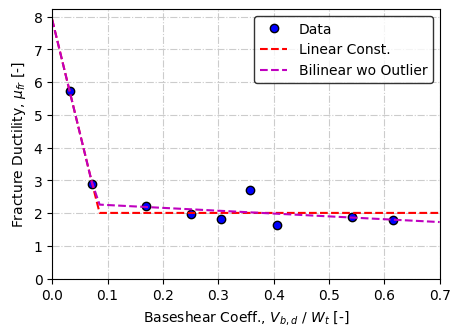

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

pop_idxs = []
outliers = []
outlier_vb = []
mu_data = bb_params_br_df.loc[buildings, "mu_fr"].values.tolist()
vb_coeffs = bdata_df.loc[buildings, "Vb_coeff"].values.tolist()

for idx in pop_idxs:
    outliers.append(mu_data.pop(idx))
    outlier_vb.append(vb_coeffs.pop(idx))

mu_data = np.array(mu_data)
vb_coeffs = np.array(vb_coeffs)

ax.plot(vb_coeffs, mu_data,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
# ax.plot(outlier_vb, outliers,
#         marker="o", ls="", mfc="m", mec="k", label="Outlier" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Linear Constant
initial_guess = [0.1, -12.0, 1.2]
mu_lincon_popt, _ = curve_fit(
linear_constant_model, vb_coeffs, mu_data, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *mu_lincon_popt)
ax.plot(x_plot, y_plot, color="r", ls="--", label="Linear Const.")

y_pred = linear_constant_model(vb_coeffs, *mu_lincon_popt)
mu_lincon_fit_metrics = calculate_fit_metrics(mu_data, y_pred, num_params=len(mu_lincon_popt))

# Bilinear Piecewise
initial_guess = [0.1, -12.0, 1.2, -1.0]
mu_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, vb_coeffs, mu_data, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *mu_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear wo Outlier")

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Fracture Ductility, $\mu_{fr}$ [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

y_pred = bilinear_piecewise_model(vb_coeffs, *mu_bilin_popt)
mu_bilin_fit_metrics = calculate_fit_metrics(mu_data, y_pred, num_params=len(mu_bilin_popt))

print(f"Linear Constant Fit Coefficient:\nx_knot = {mu_lincon_popt[0]:.4f}\nm1 = {mu_lincon_popt[1]:.4f}\nc1 = {mu_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficient:\nx_knot = {mu_bilin_popt[0]:.4f}\nm1 = {mu_bilin_popt[1]:.4f}\nc1 = {mu_bilin_popt[2]:.4f}\nm2 = {mu_bilin_popt[3]:.4f}\n")

print("Fit Metrics:")
print(pd.DataFrame([mu_lincon_fit_metrics, mu_bilin_fit_metrics], index=["Linear Constant", "Bilinear"]))

#### Model for $\mu_{r}$

Linear Constant Fit Coefficient:
x_knot = 0.0788
m1 = -100.6322
c1 = 11.4245

Bilinear Fit Coefficient:
x_knot = 0.0788
m1 = -100.6322
c1 = 11.4245
m2 = 0.0098

Fit Metrics:
                      RSS        R²    R²_adj       AIC
Linear Constant  1.635683  0.923278  0.877244 -9.346476
Bilinear         1.635669  0.923278  0.846557 -7.346555


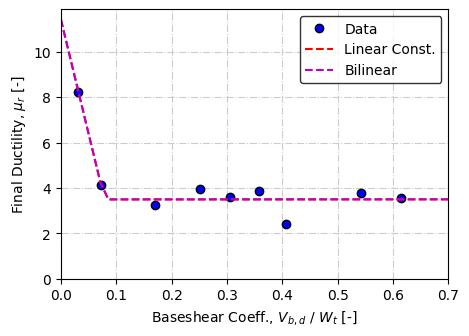

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

pop_idxs = []
outliers = []
outlier_vb = []
mu_data = bb_params_br_df.loc[buildings, "mu_r"].values.tolist()
vb_coeffs = bdata_df.loc[buildings, "Vb_coeff"].values.tolist()

for idx in pop_idxs:
    outliers.append(mu_data.pop(idx))
    outlier_vb.append(vb_coeffs.pop(idx))

mu_data = np.array(mu_data)
vb_coeffs = np.array(vb_coeffs)

ax.plot(vb_coeffs, mu_data,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
# ax.plot(outlier_vb, outliers,
#         marker="o", ls="", mfc="m", mec="k", label="Outlier" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Linear Constant
initial_guess = [0.1, -12.0, 1.2]
mu_lincon_popt, _ = curve_fit(
linear_constant_model, vb_coeffs, mu_data, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *mu_lincon_popt)
ax.plot(x_plot, y_plot, color="r", ls="--", label="Linear Const.")

y_pred = linear_constant_model(vb_coeffs, *mu_lincon_popt)
mu_lincon_fit_metrics = calculate_fit_metrics(mu_data, y_pred, num_params=len(mu_lincon_popt))

# Bilinear Piecewise
initial_guess = [0.1, -12.0, 1.2, -1.0]
mu_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, vb_coeffs, mu_data, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *mu_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear")

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"Final Ductility, $\mu_{r}$ [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

y_pred = bilinear_piecewise_model(vb_coeffs, *mu_bilin_popt)
mu_bilin_fit_metrics = calculate_fit_metrics(mu_data, y_pred, num_params=len(mu_bilin_popt))

print(f"Linear Constant Fit Coefficient:\nx_knot = {mu_lincon_popt[0]:.4f}\nm1 = {mu_lincon_popt[1]:.4f}\nc1 = {mu_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficient:\nx_knot = {mu_bilin_popt[0]:.4f}\nm1 = {mu_bilin_popt[1]:.4f}\nc1 = {mu_bilin_popt[2]:.4f}\nm2 = {mu_bilin_popt[3]:.4f}\n")

print("Fit Metrics:")
print(pd.DataFrame([mu_lincon_fit_metrics, mu_bilin_fit_metrics], index=["Linear Constant", "Bilinear"]))

#### Selected Equations

Fy    - Bilinear
E0    - Exponential Decay
b     - Bilinear without outlier
mu_fr - Bilinear Constant
mu_r  - Linear Constant

In [30]:
def _Fy_brace(Vb_coeff, Wt):
    x_knot = 0.0674
    m1 = -41.2913
    c1 = 5.2864
    m2 = -1.5976
    return bilinear_piecewise_model(Vb_coeff, x_knot, m1, c1, m2) * Vb_coeff * Wt

def _E0_brace(Vb_coeff, Wt, hi, brace_angle):
    a = 1810.2138
    b = -12.5761
    c = 508.4157
    E0_normalised = exponential_shifted(Vb_coeff, a, b, c) 
    normalisation_factor = Vb_coeff * Wt * np.sin(brace_angle) * np.cos(brace_angle) ** 2 / hi
    return E0_normalised * normalisation_factor

def _b_brace(Vb_coeff):
    x_knot = 0.1148
    m1 = -1.0342
    c1 = 0.0256
    m2 = -0.0277
    return bilinear_piecewise_model(Vb_coeff, x_knot, m1, c1, m2)

def _mu_fr_brace(Vb_coeff):
    x_knot = 0.0852
    m1 = -69.2558
    c1 = 7.9101
    return linear_constant_model(Vb_coeff, x_knot, m1, c1)
    
def _mu_r_brace(Vb_coeff):
    x_knot = 0.0788
    m1 = -100.6322
    c1 = 11.4245
    return linear_constant_model(Vb_coeff, x_knot, m1, c1)

def br_backbone_params(Vb_coeff, Wt, hi, brace_angle):
    Fy = float(np.round(_Fy_brace(Vb_coeff, Wt), 3))
    E0 = float(np.round(_E0_brace(Vb_coeff, Wt, hi, brace_angle), 3))
    b = np.round(_b_brace(Vb_coeff), 3)
    mu_fr = np.round(_mu_fr_brace(Vb_coeff), 3)
    mu_r = np.round(_mu_r_brace(Vb_coeff), 3)
    return Fy, E0, b, mu_fr, mu_r

def get_approximate_br_backbone(Vb_coeff, Wt, hi, aspect):
    """ returns the points of backbone curve for the soft storey system calculated
    using the fitted predictions equations for Fy, E0, b, mu_fr and mu_r.
    aspect = aspect ratio of the braced_bay (height / width)"""

    brace_angle = np.arctan(aspect)
    
    Fy, E0, b, mu_fr, mu_r = br_backbone_params(Vb_coeff, Wt, hi, brace_angle)
    
    dy = Fy / E0
    dfr = mu_fr * dy
    dr = mu_r * dy
    
    p1 = [0, 0]
    p2 = [dy, Fy]
    p3 = [dfr, Fy + b * E0 * (dfr - dy)]
    p4 = [dr, 0]

    return np.column_stack([p1, p2, p3, p4]).T

#### Comparison with the Originals

(385698.002, 17082.503, np.float64(-0.007), np.float64(5.718), np.float64(8.239))

(554279.152, 28050.626, np.float64(-0.049), np.float64(2.885), np.float64(4.123))

(1216289.146, 38387.684, np.float64(-0.095), np.float64(2.01), np.float64(3.495))

(1696978.156, 45965.19, np.float64(-0.097), np.float64(2.01), np.float64(3.495))

(1984889.584, 52302.382, np.float64(-0.098), np.float64(2.01), np.float64(3.495))

(2230854.49, 59084.433, np.float64(-0.1), np.float64(2.01), np.float64(3.495))

(2439947.668, 66015.447, np.float64(-0.101), np.float64(2.01), np.float64(3.495))

(2894120.315, 86469.158, np.float64(-0.105), np.float64(2.01), np.float64(3.495))

(3066278.307, 97994.155, np.float64(-0.107), np.float64(2.01), np.float64(3.495))



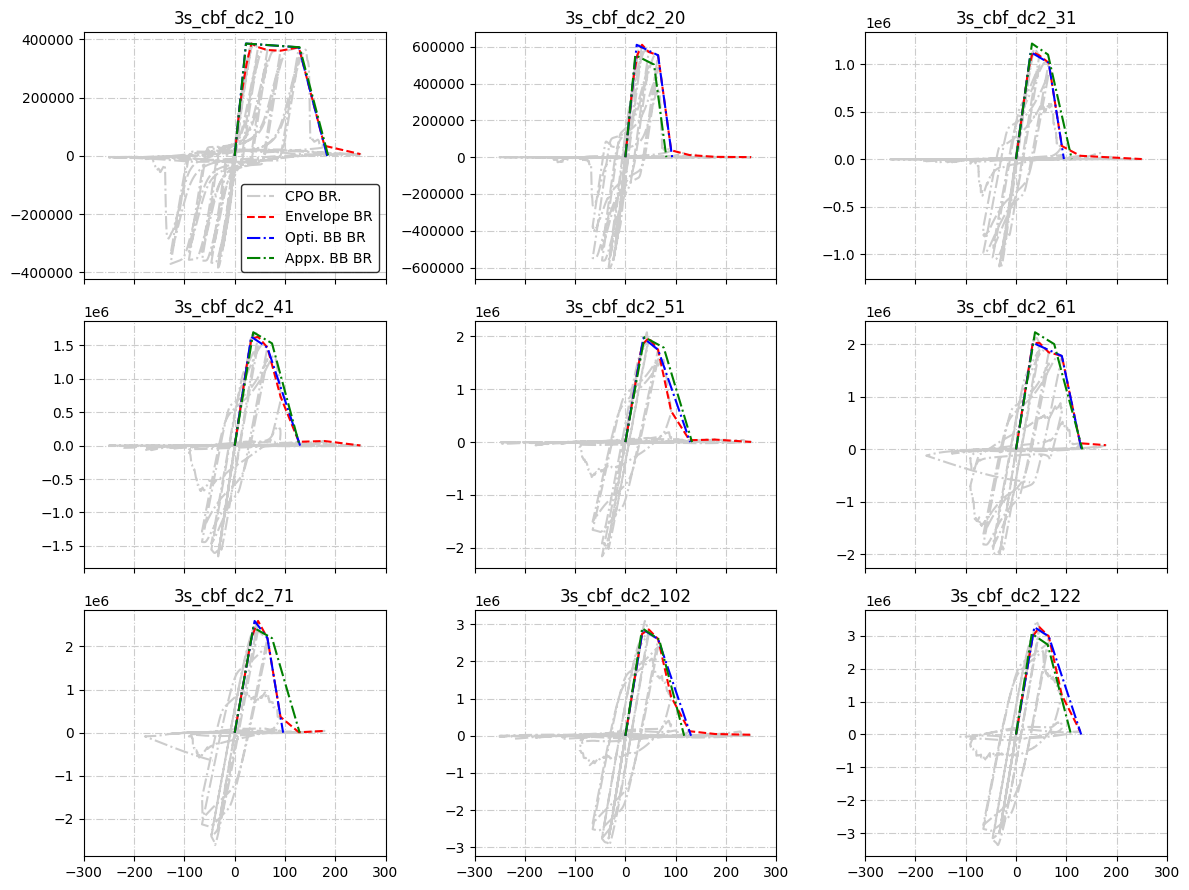

In [31]:
# Simplified backbones for the frame contribution
total_n = len(buildings)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

appx_bb_br = {}
appx_bb_params_br = {}

for b, ax in zip(buildings, axs.flatten()):
    
    vb_coeff = bdata_df.loc[b, "Vb_coeff"]
    Wt = bdata_df.loc[b, "seismic_mass"] * 9.81

    appx_bb = get_approximate_br_backbone(vb_coeff, Wt, storey_height, aspect)
    appx_bb_br[b] = appx_bb

    appx_bb_params_br[b] = (np.concatenate([appx_bb[1:, [1,0]], -appx_bb[1:, [1,0]]]) / gammas[b]
                            ).flatten().tolist()

    brace_angle = np.arctan(aspect)
    print(br_backbone_params(vb_coeff, Wt, storey_height, brace_angle))
    print()

    bb_env_br = bb_envs_br[b]
    envelope_br = envelopes_br[b]

    cpoc_br = cpocs_br[b]
    ax.plot(cpoc_br[:, 0], cpoc_br[:, 1], color="0.8", ls="-.", label="CPO BR.")
    ax.plot(envelope_br[:, 0], envelope_br[:, 1], color="r", ls="--", label="Envelope BR")
    ax.plot(bb_env_br[:, 0], bb_env_br[:, 1], color="b", ls="-.", label="Opti. BB BR")
    ax.plot(appx_bb[:, 0], appx_bb[:, 1], color="g", ls="-.", label="Appx. BB BR")

    ax.set_title(b)
    ax.grid(ls="-.", color="0.8")

    
ax.set_xlim(-300, 300)
leg = axs.flatten()[0].legend(loc="lower right")
frame = leg.get_frame()
frame.set_edgecolor("k")

plt.tight_layout()

## 2.5 Parameters and Configs for the Optimisation

In [32]:
### SAVE SOME STUFF FOR USING LATER
### CREATE CONFIGS FOR SDOF FITTING

folder = cfg["proc_data"]["sdof_fitting"]

configs_3s_ss = []
configs_3s = []

popsize = 15
cores = 50
seed = 1
tol = 1e-8
mutation = (0.5, 1)
recombination = 0.7
dU_max = 2.0            # we can make this larger because the analysis is stable

for b in buildings:

    # backbone parameters for the soft storey system
    ss_data = bb_params_ss[b].copy()
    # convert to SDOF coordinates - using the gamma for the full system to make sure that all SDOFs have a consistent conversion
    ss_data["Fy"] /= gammas[b]
    ss_data["du"] /= gammas[b]

    filename = f"{b}_mechanism_sdof_parameters.json"
    fp_ss_sdof_params = folder / "sdof_parameters" / filename
    with open(fp_ss_sdof_params, "w") as file:
        json.dump(ss_data, file, indent=4)

    # backbone paraemeters for the full system - converted to SDOF coordinates using the full system gamma
    steel02_bb_params = [v for v in ss_data.values()]   
    hysteretic_bb_params = (np.array(bb_params_br[b]) / gammas[b]).tolist()
    data = {
        "steel02_bb_params": steel02_bb_params,
        "hysteretic_bb_params": hysteretic_bb_params,
        "mass": m_stars[b]
    }
    filename = f"{b}_sdof_parameters.json"
    fp_sdof_params = folder / "sdof_parameters" / filename
    with open(fp_sdof_params, "w") as file:
        json.dump(data, file, indent=4)

    # mdof hysteresis data for the soft storey system converted to equivalent sdof coordinates
    eq_sdof_cpoc_ss_data = cpocs_ss[b] / gammas[b]
    fp_ss_test_data = folder / "test_data" / f"{b}_mechanism_eq_sdof_cpo.csv"
    np.savetxt(fp_ss_test_data, eq_sdof_cpoc_ss_data, delimiter=",")  

    # mdof hysteresis data for the full system converted to equivalent sdof coordinates
    eq_sdof_cpoc_data = cpocs[b] / gammas[b]
    fp_test_data = folder / "test_data" / f"{b}_eq_sdof_cpo.csv"
    np.savetxt(fp_test_data, eq_sdof_cpoc_data, delimiter=",") 

    # displacement data for the cyclic pushover curve of the full system, converted to equivalent sdof coordinates
    fp_target_disps = folder / "target_displacements" / f"{b}_target_displacements.csv"  
    np.savetxt(fp_target_disps, cpocs_ss[b][:, 0] / gammas[b], delimiter=",") 

    # parameter bounds for a1 and a2 of the Steel01 material
    bounds = [(0, 0.5), (1.0, 5.0)]     # bounds for a1 and a2
    fp_steel01_param_bounds = folder / "parameter_bounds" / f"{b}_steel_01_parameter_bounds.csv"
    np.savetxt(fp_steel01_param_bounds, bounds, delimiter=",")  

    # parameter bounds for a1, a2, R0, cR1, cR2 of the Steel02 material
    bounds = [(0, 0.5), (1.0, 5.0), (15, 20), (0.5, 0.95), (0.01, 1.0)]     # bounds for a1 and a2
    fp_steel02_param_bounds = folder / "parameter_bounds" / f"{b}_steel_02_parameter_bounds.csv"
    np.savetxt(fp_steel02_param_bounds, bounds, delimiter=",") 

    # parameter bounds for a1, a2, R0, cR1, cR2 of the Steel02 material and pinch_X and pinch_Y, damage_1, damage_2, and beta for the Hysteretic material
    bounds = [(0, 0.5), (1.0, 6.0), (10, 25), (0.5, 0.95), (0.01, 1.0), (0.01, 1.0), (0.01, 1.0), (0, 1.0), (0, 1.0), (0, 1.0)]     # bounds for a1 and a2
    fp_steel02_hysteretic_param_bounds = folder / "parameter_bounds" / f"{b}_steel02_hysteretic_parameter_bounds.csv"
    np.savetxt(fp_steel02_hysteretic_param_bounds, bounds, delimiter=",") 

    # steel02 optimisation for soft storey systems
    config_ss = {
        "results_folder": cfg["proc_data"]["sdof_optimisation"],
        "result_name": "_mechanism_steel02_optimisation.pickle",
        "building_tag": b,
        "sdof_params": fp_ss_sdof_params,             
        "test_data": fp_ss_test_data,        
        "displacements": fp_target_disps,
        "dU_max": dU_max,
        "param_bounds": fp_steel02_param_bounds,
        "initialise_model_func": "initialise_steel02_model",
        "popsize": popsize,
        "cores": cores,
        "seed": seed,
        "tol": tol,
        "mutation": mutation,
        "recombination": recombination,
    }

    config = {
        "results_folder": cfg["proc_data"]["sdof_optimisation"],
        "result_name": "_steel02_and_hysteretic_optimisation.pickle",
        "building_tag": b,
        "sdof_params": fp_sdof_params,             
        "test_data": fp_test_data,        
        "displacements": fp_target_disps,
        "dU_max": dU_max,
        "param_bounds": fp_steel02_hysteretic_param_bounds,
        "initialise_model_func": "steel02_and_hysteretic",
        "popsize": popsize,
        "cores": cores,
        "seed": seed,
        "tol": tol,
        "mutation": mutation,
        "recombination": recombination,
    }

    if bdata_df.loc[b, "n_storeys"] == 3:
        configs_3s_ss.append(config_ss)
        configs_3s.append(config)


Only uncomment the next block if you want to create new files for running the optimisation

In [33]:
# from phd_project.scripts.templates.copy_templates_to_folders import configure_optimisation_batch_run
# # Create the batch run files
# src = cfg["templates"]["group_sdof_optimisation"]

# dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "optimisation_batch_run_3s_mechanism_steel02.py"
# configure_optimisation_batch_run(src, dst, configs_3s_ss)


# dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "optimisation_batch_run_3s_steel02_and_hysteretic.py"
# configure_optimisation_batch_run(src, dst, configs_3s)

If you have created new files you now need to run the batch files that that do the optimisation

## 2.6 Optimisation Results

### 2.6.1 Cyclic Pushovers

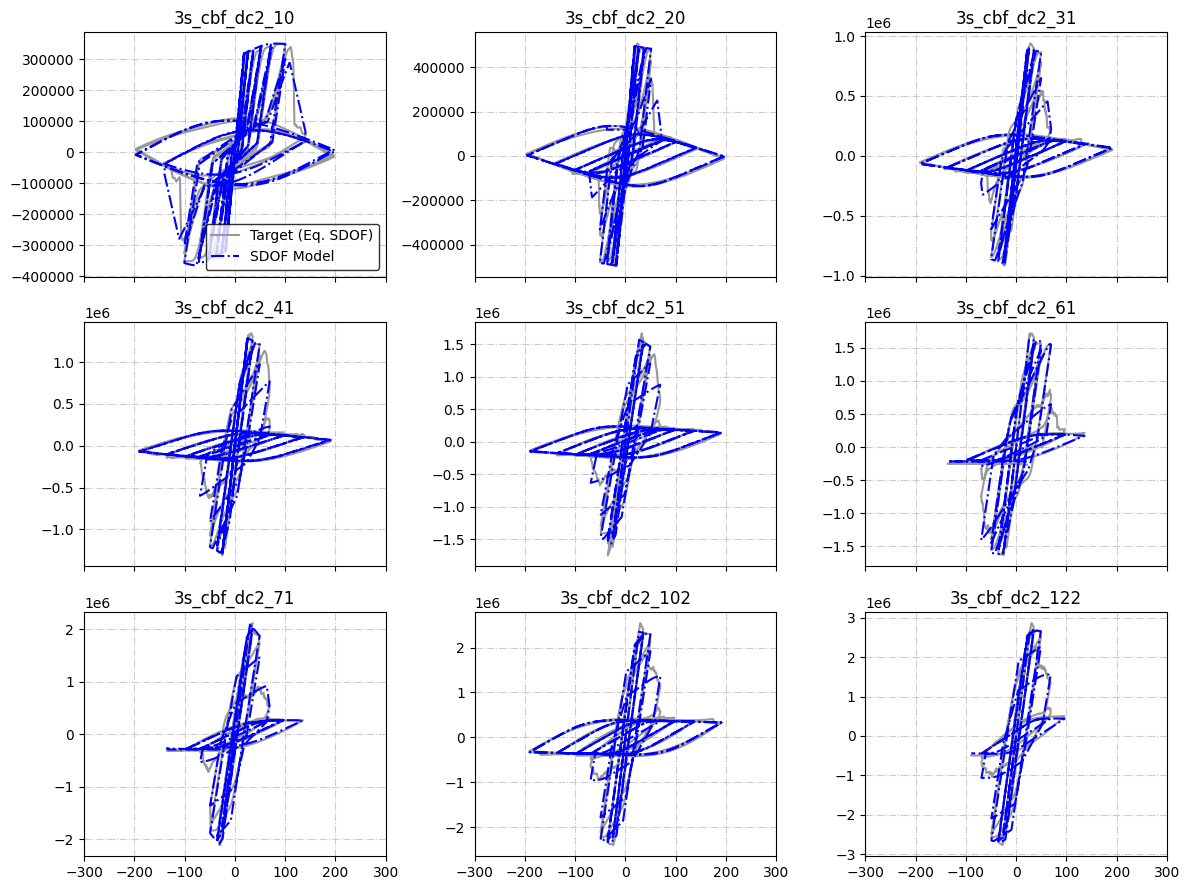

In [34]:
# Simplified backbones for the brace contribution
total_n = len(configs_3s)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

collapse_residual =True

optimised_hystersis_params = {}
target_responses = {}
simulated_responses = {}

for config, ax, b in zip(configs_3s, axs.flatten(), buildings):
    # load result
    result_file = config["results_folder"] / f"{config['building_tag']}{config['result_name']}"
    with open(result_file, "rb") as file:
        result = pickle.load(file)

    # process the result and save optimised parameters
    steel02_params = result.x[:5]
    hysteretic_params = result.x[5:]
    optimised_params = {
        "steel02_hyst_params": steel02_params.tolist(),
        "hysteretic_hyst_params": hysteretic_params.tolist()
    }

    optimised_params_file = config["results_folder"] / f"{config['building_tag']}_optimised_parameters.json"
    with open(optimised_params_file, "w") as file:
        json.dump(optimised_params, file, indent=4)

    optimised_hystersis_params[b] = optimised_params

    target_response, sim_response = validate_optimised_parameters(
        config, result
    )

    target_responses[b] = target_response
    simulated_responses[b] = sim_response

    ax.plot(target_response[:, 0], target_response[:, 1], color="0.6", ls="-", label="Target (Eq. SDOF)")
    ax.plot(sim_response[:, 0], sim_response[:, 1], color="b", ls="-.", label="SDOF Model")
    
    
    ax.set_title(config["building_tag"])
    ax.grid(ls="-.", color="0.8")

ax.set_xlim(-300, 300)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

### 2.6.2 Statistics of Optimised Parameters

In [35]:
steel_param_tags = ["a1", "a2", "R0", "cR1", "cR2"]
hyst_param_tags = ["pinchX", "pinchY", "damage1", "damage2", "beta"]

results_dict = {}
for b, params in optimised_hystersis_params.items():
    steel_params = params["steel02_hyst_params"]
    hyst_params = params["hysteretic_hyst_params"]
    vals = steel_params + hyst_params
    tags = steel_param_tags + hyst_param_tags

    results_dict[b] = {t:v for t, v in zip(tags, vals)}

hyst_param_df = pd.DataFrame.from_dict(results_dict, orient="index")
hyst_param_df


,a1,a2,R0,cR1,cR2,pinchX,pinchY,damage1,damage2,beta
3s_cbf_dc2_10,3.123135e-01,3.239177,10.000001,0.722867,0.131679,0.862336,0.157630,0.008398,4.556857e-09,0.336717
3s_cbf_dc2_20,5.194051e-02,2.417808,24.336378,0.762932,0.139275,0.678482,0.439938,0.055101,1.041282e-04,0.360791
3s_cbf_dc2_31,7.855739e-02,3.025603,25.000000,0.806143,0.226017,0.105202,0.251738,0.087724,1.535731e-10,0.420473
3s_cbf_dc2_41,1.402351e-01,5.618967,18.200199,0.767624,0.546255,0.215509,0.480539,0.159929,2.464503e-09,0.393951
3s_cbf_dc2_51,8.658327e-02,5.061951,24.999935,0.719751,0.019563,0.319255,0.794949,0.203141,7.693190e-10,0.446513
3s_cbf_dc2_61,4.825411e-02,1.509951,18.768774,0.893233,0.390815,0.183077,0.319839,0.119045,2.840445e-02,0.193975
3s_cbf_dc2_71,2.299175e-01,4.076995,10.380748,0.932060,0.671615,0.315704,0.856455,0.175072,3.944136e-04,0.343640
3s_cbf_dc2_102,3.573389e-02,2.391915,24.999993,0.950000,0.866128,0.294445,0.888595,0.201869,0.000000e+00,0.280794
3s_cbf_dc2_122,6.686478e-08,3.785590,24.999998,0.500000,0.016724,0.301497,1.000000,0.224161,2.671641e-09,0.255498


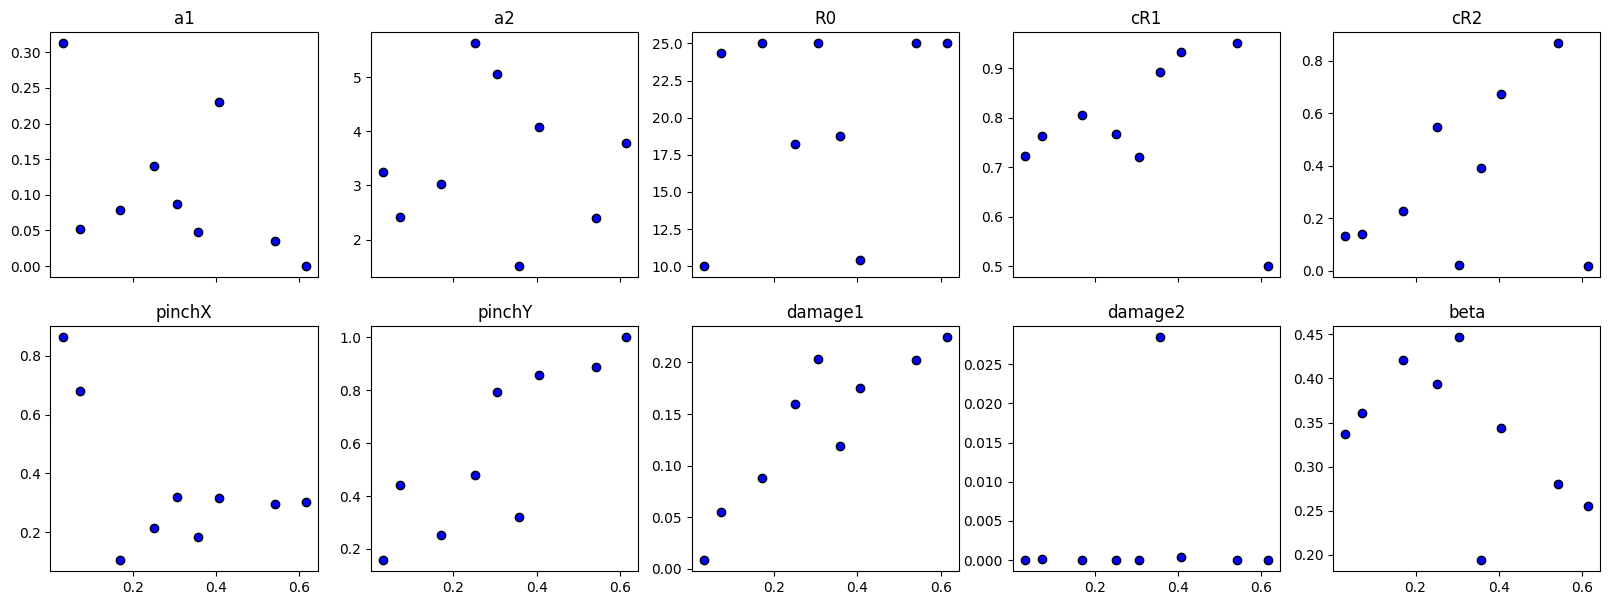

In [36]:
fig, axs = plt.subplots(2, 5, figsize=(20, 7), sharex=True) 
axs = axs.flatten()


for col, ax in zip(hyst_param_df.columns, axs):
    ax.plot(bdata_df.loc[buildings, "Vb_coeff"], hyst_param_df.loc[buildings, col],
            marker="o", ls="", mfc="b", mec="k" )
    ax.set_title(col)
    ...

We want to be able to draw some general conclusions and possibly parameterise the hysteretic parameters. The following is a simple statistical analysis of the parameters to see where simplifications can be made

In [37]:
hyst_param_stats = hyst_param_df.describe()

Inspecting the plot above the following simplifications seem logical...
- a1 -> mean, ~= 0.14
- a2 -> mean, ~= 3.45
- R0 -> mean, ~= 20.18
- cR1 -> mean, ~= 0.78
- cR2 -> mean ~= 0.30
- PinchX -> bilinear or mean?
- PinchY -> linear w Vb
- damage1 -> linear w Vb
- damage2 -> 0. There is only one case where this is not 0.
- beta -> mean, ~= 0.337

#### Model for Pinch X

Lincon Fit Coefficients:
x_knot = 0.1684
m = -4.4956
c = 1.0047

Bilinear Fit Coefficients:
x_knot = 0.1698
m1 = -5.0467
c1 = 1.0325
m2 = 0.3478

                      RSS        R²    R²_adj        AIC
Linear Constant  0.040342  0.916316  0.866106 -42.668319
Bilinear         0.022285  0.953773  0.907545 -46.009570


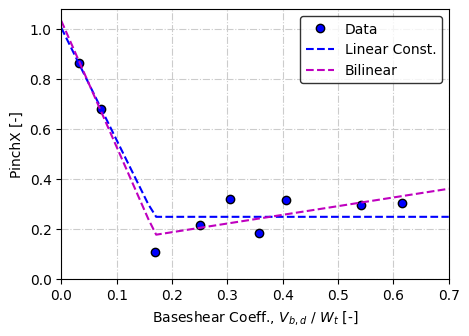

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

pinchX = hyst_param_df.loc[buildings, "pinchX"]
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], pinchX,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Piecewise Linear Constant
initial_guess = [0.2, -8, 0.9]
pinchX_lincon_popt, _ = curve_fit(
linear_constant_model, bdata_df.loc[buildings, "Vb_coeff"], pinchX, 
p0=initial_guess
)
y_plot = linear_constant_model(x_plot, *pinchX_lincon_popt)
ax.plot(x_plot, y_plot, color="b", ls="--", label="Linear Const.")

y_lincon_pred = linear_constant_model(bdata_df.loc[buildings, "Vb_coeff"], *pinchX_lincon_popt)
pinchX_lincon_fit_metrics = calculate_fit_metrics(pinchX, y_lincon_pred, num_params=len(pinchX_lincon_popt))

# Piecewise Bilinear
initial_guess = [0.2, -8, 0.9, 0.01]
pinchX_bilin_popt, _ = curve_fit(
bilinear_piecewise_model, bdata_df.loc[buildings, "Vb_coeff"], pinchX, 
p0=initial_guess
)
y_plot = bilinear_piecewise_model(x_plot, *pinchX_bilin_popt)
ax.plot(x_plot, y_plot, color="m", ls="--", label="Bilinear")

y_bilin_pred = bilinear_piecewise_model(bdata_df.loc[buildings, "Vb_coeff"], *pinchX_bilin_popt)
pinchX_bilin_fit_metrics = calculate_fit_metrics(pinchX, y_bilin_pred, num_params=len(pinchX_bilin_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"PinchX [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Lincon Fit Coefficients:\nx_knot = {pinchX_lincon_popt[0]:.4f}\nm = {pinchX_lincon_popt[1]:.4f}\nc = {pinchX_lincon_popt[2]:.4f}\n")
print(f"Bilinear Fit Coefficients:\nx_knot = {pinchX_bilin_popt[0]:.4f}\nm1 = {pinchX_bilin_popt[1]:.4f}\nc1 = {pinchX_bilin_popt[2]:.4f}\nm2 = {pinchX_bilin_popt[3]:.4f}\n")

print(pd.DataFrame([pinchX_lincon_fit_metrics, pinchX_bilin_fit_metrics], index=["Linear Constant", "Bilinear"]))

#### Model for PinchY

Linear Fit Coefficients:
m = 1.3196
c = 0.1735

             RSS        R²    R²_adj        AIC
Linear  0.229412  0.704939  0.606585 -29.025146


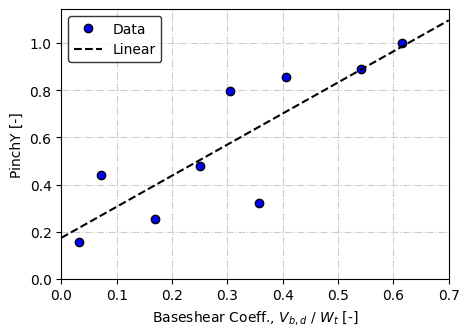

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

pinchY = hyst_param_df.loc[buildings, "pinchY"]
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], pinchY,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Linear
initial_guess = [8, 0.9]
pinchY_lin_popt, _ = curve_fit(
linear_model, bdata_df.loc[buildings, "Vb_coeff"], pinchY, 
p0=initial_guess
)
y_plot = linear_model(x_plot, *pinchY_lin_popt)
ax.plot(x_plot, y_plot, color="k", ls="--", label="Linear")

y_lin_pred = linear_model(bdata_df.loc[buildings, "Vb_coeff"], *pinchY_lin_popt)
pinchY_lin_fit_metrics = calculate_fit_metrics(pinchY, y_lin_pred, num_params=len(pinchY_lin_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"PinchY [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Linear Fit Coefficients:\nm = {pinchY_lin_popt[0]:.4f}\nc = {pinchY_lin_popt[1]:.4f}\n")

print(pd.DataFrame([pinchY_lin_fit_metrics], index=["Linear"]))

#### Model for Damage1

Linear Fit Coefficients:
m = 0.3332
c = 0.0354

             RSS        R²    R²_adj        AIC
Linear  0.009204  0.791528  0.722038 -57.967792


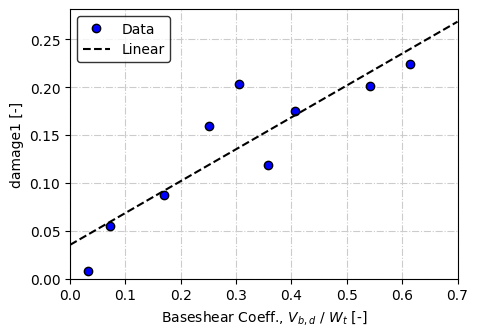

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5)) 

dam1 = hyst_param_df.loc[buildings, "damage1"]
ax.plot(bdata_df.loc[buildings, "Vb_coeff"], dam1,
        marker="o", ls="", mfc="b", mec="k", label="Data" )
ax.grid(ls="-.", color="0.8")

# Fits:
# Linear
initial_guess = [8, 0.9]
dam1_lin_popt, _ = curve_fit(
linear_model, bdata_df.loc[buildings, "Vb_coeff"], dam1, 
p0=initial_guess
)
y_plot = linear_model(x_plot, *dam1_lin_popt)
ax.plot(x_plot, y_plot, color="k", ls="--", label="Linear")

y_lin_pred = linear_model(bdata_df.loc[buildings, "Vb_coeff"], *dam1_lin_popt)
dam1_lin_fit_metrics = calculate_fit_metrics(dam1, y_lin_pred, num_params=len(dam1_lin_popt))

ax.set_xlabel(r"Baseshear Coeff., $V_{b,d}$ / $W_t$ [-]")
ax.set_ylabel(r"damage1 [-]")
ax.set_ylim(0)
ax.set_xlim(0, 0.7)

leg = ax.legend()
frame = leg.get_frame()
frame.set_edgecolor("k")

print(f"Linear Fit Coefficients:\nm = {dam1_lin_popt[0]:.4f}\nc = {dam1_lin_popt[1]:.4f}\n")

print(pd.DataFrame([dam1_lin_fit_metrics], index=["Linear"]))

#### Prediction Equations

In [41]:
def _pinchX(Vb_coeff):
    x_knot = 0.1698
    m1 = -5.0467
    c1 = 1.0325
    m2 = 0.3478
    return bilinear_piecewise_model(Vb_coeff, x_knot, m1, c1, m2)
    
def _pinchY(Vb_coeff):
    m = 1.3196
    c = 0.1735
    return linear_model(Vb_coeff, m, c)

def _damage1(Vb_coeff):
    m = 0.3332
    c = 0.0354
    return linear_model(Vb_coeff, m, c)

def get_approximate_hysteretic_hyst_params(Vb_coeff):
    """ returns pinchX, pinchY, damage1, damage2, beta"""
    pinchX = _pinchX(Vb_coeff)
    pinchY = _pinchY(Vb_coeff)
    d1 = _damage1(Vb_coeff)
    d2 = 0
    beta = 0.337

    return [pinchX, pinchY, d1, d2, beta]

def get_approximate_steel02_hyst_params():
    """ returns a1, a2, R0, cR1, cR2"""
    return hyst_param_stats.loc["mean", ["a1", "a2", "R0", "cR1", "cR2"]].values.tolist()

In [42]:
get_approximate_steel02_hyst_params()

[0.10928171323806772,
 3.458661900789691,
 20.187336087317114,
 0.7838453700836109,
 0.334230252273704]

In [43]:
get_approximate_hysteretic_hyst_params(bdata_df.loc[b, "Vb_coeff"])

[0.33036916399999977,
 np.float64(0.9848956479999998),
 np.float64(0.24027801599999998),
 0,
 0.337]

#### Comparison with MDOF and optimised SDOF model

Create the files needed to build and run the approximate sdof models

In [44]:
for b in buildings:
    # make the target folder
    folder = cfg["proc_data"]["approx_sdof_systems"]
    folder.mkdir(parents=True, exist_ok=True)

    # approximate backbone parameters for the full system - converted to SDOF coordinates using the full system gamma
    appx_steel02_bb_params = [v for v in appx_bb_params_ss[b].values()][:-1]   
    appx_hysteretic_bb_params = appx_bb_params_br[b]
    bb_data = {
        "steel02_bb_params": appx_steel02_bb_params,
        "hysteretic_bb_params": appx_hysteretic_bb_params,
        "mass": m_stars[b]
    }
    filename = f"{b}_appx_sdof_bb_parameters.json"
    fp_bb_params = folder / filename
    with open(fp_bb_params, "w") as file:
        json.dump(bb_data, file, indent=4)

    # approximate hystersis parameters for the full system
    hyst_data = {
        "steel02_hyst_params": get_approximate_steel02_hyst_params(),
        "hysteretic_hyst_params": get_approximate_hysteretic_hyst_params(bdata_df.loc[b, "Vb_coeff"]),
    }
    filename = f"{b}_appx_sdof_hyst_parameters.json"
    fp_hyst_params = folder / filename
    with open(fp_hyst_params, "w") as file:
        json.dump(hyst_data, file, indent=4)

In [45]:
batch = []

for b in buildings:
    # make the target folder
    folder = ROOT / f"{b}_appx_sdof"
    folder.mkdir(parents=True, exist_ok=True)

    # copy the analysis template
    src_run = cfg["templates"]["run_cyclic_pushover"]
    dst_run = folder / "run_run_cyclic_pushover.py"
    copy_file(src_run, dst_run)

    # now copy the structural model
    src_model = cfg["templates"]["model_cbf_sdof"]
    dst_model = folder / "structural_model.py"

    fp_bb_params = cfg["proc_data"]["approx_sdof_systems"] / f"{b}_appx_sdof_bb_parameters.json"
    with open(fp_bb_params, "r") as file:
        sdof_bb_params = json.load(file)

    fp_hyst_params = cfg["proc_data"]["approx_sdof_systems"] / f"{b}_appx_sdof_hyst_parameters.json"    
    with open(fp_hyst_params, "r") as file:
        sdof_hyst_params = json.load(file)
    
    ops_updates = {
        k:v for k,v in (sdof_bb_params|sdof_hyst_params).items()
    }

    copy_structural_model(src_model, dst_model, ops_updates=ops_updates)

    # now copy the config 
    src_config = cfg["templates"]["config_cyclic_pushover"]
    dst_config = folder / "config_cyclic_pushover.py"

    fp_target_disps = cfg["proc_data"]["sdof_fitting"] / "target_displacements" / f"{b}_target_displacements.csv" 
    target_disps = np.loadtxt(fp_target_disps, delimiter=",") 
    
    config_changes = {
        "ctrl_node": 2,
        "displacements": target_disps.tolist()
        }

    copy_analysis_config(src_config, dst_config, update_config=config_changes)
    
    batch.append({
        "script": dst_run,
        "config": [dst_config]
        })
    
batch_run_src = cfg["templates"]["batch_run"]
batch_run_dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "approx_sdof_3s_cyclic_pushover.py"
configure_batch_run_file(batch_run_src, batch_run_dst, batch)

Run the batch file: "approx_sdof_3s_cyclic_pushover.py" to get the results needed for the following plots

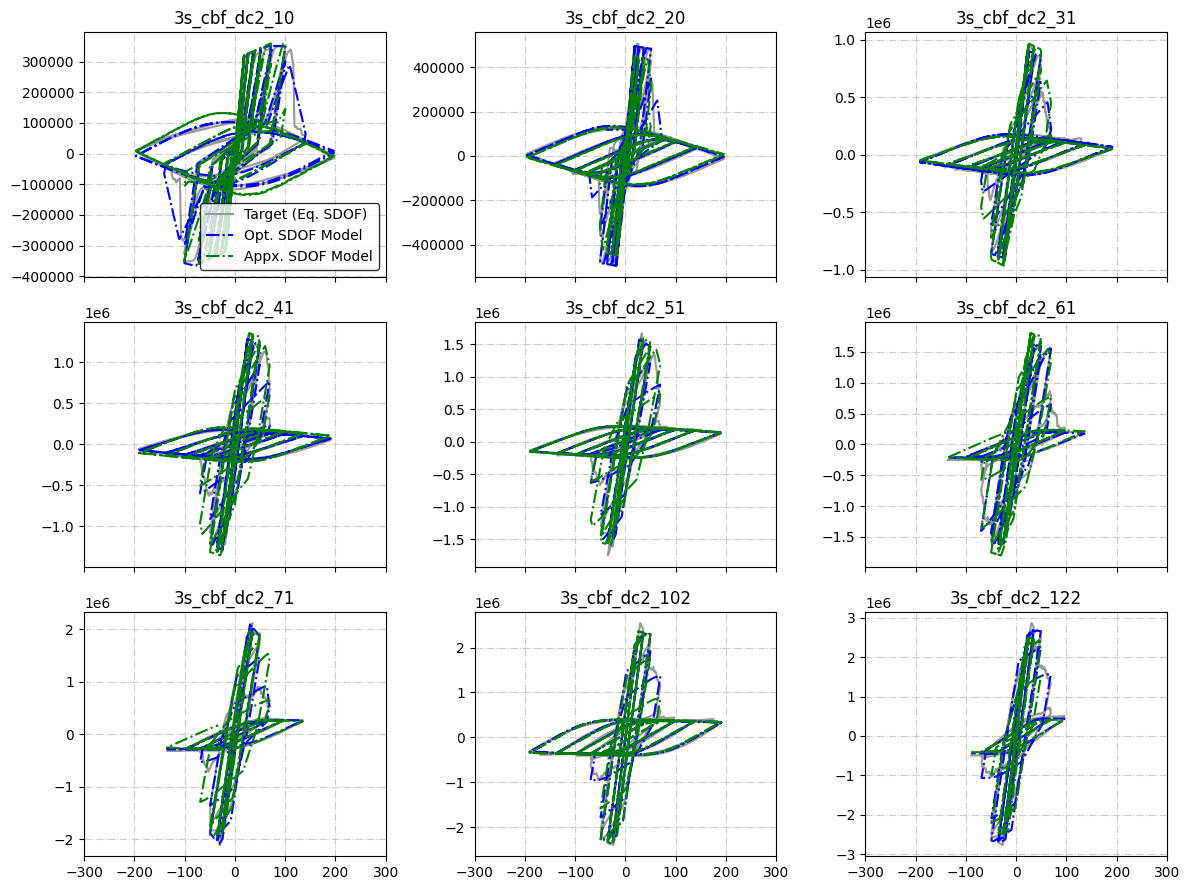

In [46]:
# Simplified backbones for the brace contribution
total_n = len(configs_3s)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

for config, ax, b in zip(configs_3s, axs.flatten(), buildings):

    # load the approximate sdof response
    folder = ROOT / f"{b}_appx_sdof"
    appx_sdof = np.loadtxt(folder / "cyclic_pushover" / "po_curve.csv", delimiter=",")

    target = target_responses[b]

    target, appx_sdof, common_s = standardise_responses(target, appx_sdof)

    opti_sdof = simulated_responses[b]

    ax.plot(target[:, 0], target[:, 1], color="0.6", ls="-", label="Target (Eq. SDOF)")
    ax.plot(opti_sdof[:, 0], opti_sdof[:, 1], color="b", ls="-.", label="Opt. SDOF Model")
    ax.plot(appx_sdof[:, 0], appx_sdof[:, 1], color="g", ls="-.", label="Appx. SDOF Model")
    
    
    ax.set_title(config["building_tag"])
    ax.grid(ls="-.", color="0.8")

ax.set_xlim(-300, 300)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

## 2.7 IDA Assessment

The results for the 3s buildings look good for the cyclic pushovers but we need to see how they look with some time histories as well to see if they are ballpark

Create some files to run IDAs for a single record for each of the 3s MDOF Buildings

In [47]:
batch = []

for b in buildings:
    # copy files that don't need changing:
    src_proc = cfg["templates"]["ida_process_recorder_roof_drift"]
    dst_proc = ROOT / b / "ida_process_recorders.py"
    copy_file(src_proc, dst_proc)

    src_im = cfg["templates"]["config_im_SA"]
    dst_im = ROOT / b / "config_im.py"
    copy_file(src_im, dst_im)

    src_inj = cfg["templates"]["nltha_injection_update_damping"]
    dst_inj = ROOT / b / "injection_functions.py"
    copy_file(src_inj, dst_inj)

    src_run = cfg["templates"]["run_ida_htf_single_record"]
    dst_run = ROOT / b / "run_ida_htf_single_record.py"
    copy_file(src_run, dst_run)

    # now copy the config 
    src_config = cfg["templates"]["config_ida_htf"]
    dst_config = ROOT / b / "config_ida_htf_120111.py"

    changes = {
        "results_folder_name": "ida_120111",
        "record_filenames": ['fema_p695_120111.json'],
    }

    copy_analysis_config(src_config, dst_config, **changes)
    
    batch.append({
        "script": dst_run,
        "config": [dst_config]
        })
    
batch_run_src = cfg["templates"]["batch_run"]
batch_run_dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "mdof_3s_idas_120111.py"
configure_batch_run_file(batch_run_src, batch_run_dst, batch)

Create some files to run full IDAs for to calculate the fragility of the MDOF frames

In [48]:
# most of the files are the same - just need a new run and config file
batch = []

for b in buildings:

    src_run = cfg["templates"]["run_ida_htf_multiple_records"]
    dst_run = ROOT / b / "run_ida_htf_multiple_records.py"
    copy_file(src_run, dst_run)

    # now copy the config 
    src_config = cfg["templates"]["config_ida_htf"]
    dst_config = ROOT / b / "config_ida_htf_femap695_set.py"

    changes = {
        "results_folder_name": "ida_femap695",
        "record_filenames": ['fema_p695_120111.json',
                             'fema_p695_120121.json',
                             'fema_p695_120411.json',
                             'fema_p695_120521.json',
                             'fema_p695_120611.json',
                             'fema_p695_120621.json',
                             'fema_p695_120711.json',
                             'fema_p695_120721.json',
                             'fema_p695_120811.json',
                             'fema_p695_120821.json',
                             'fema_p695_120911.json',
                             'fema_p695_120921.json',
                             'fema_p695_121011.json',
                             'fema_p695_121021.json',
                             'fema_p695_121111.json',
                             'fema_p695_121211.json',
                             'fema_p695_121221.json',
                             'fema_p695_121321.json',
                             'fema_p695_121411.json',
                             'fema_p695_121421.json',
                             'fema_p695_121511.json',
                             'fema_p695_121711.json',
                             ],
    }

    copy_analysis_config(src_config, dst_config, **changes)
    
    batch.append({
        "script": dst_run,
        "config": [dst_config]
        })
    
batch_run_src = cfg["templates"]["batch_run"]
batch_run_dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "mdof_3s_ida_femaP695.py"
configure_batch_run_file(batch_run_src, batch_run_dst, batch)

Create some files for running a full IDA on the SDOF Systems

In [49]:
batch = []

for b in buildings:
    # make the target folder
    folder = ROOT / f"{b}_sdof"
    folder.mkdir(parents=True, exist_ok=True)

    # copy files that don't need changing:
    src_proc = cfg["templates"]["ida_process_recorder_x_displacement"]
    dst_proc = folder / "ida_process_recorders.py"
    copy_file(src_proc, dst_proc)

    src_im = cfg["templates"]["config_im_SA"]
    dst_im = folder / "config_im.py"
    copy_file(src_im, dst_im)

    src_inj = cfg["templates"]["nltha_injection_update_damping"]
    dst_inj = folder / "injection_functions.py"
    copy_file(src_inj, dst_inj)

    src_run = cfg["templates"]["run_ida_htf_multiple_records"]
    dst_run = folder / "run_ida_htf_multiple_records.py"
    copy_file(src_run, dst_run)

    # now copy the structural model
    src_model = cfg["templates"]["model_cbf_sdof"]
    dst_model = folder / "structural_model.py"

    fp_sdof_params = cfg["proc_data"]["sdof_parameters"] / f"{b}_sdof_parameters.json"
    with open(fp_sdof_params, "r") as file:
        sdof_params = json.load(file)

    fp_optimisation_params = cfg["proc_data"]["sdof_optimisation"] / f"{b}_optimised_parameters.json"    
    with open(fp_optimisation_params, "r") as file:
        hyst_params = json.load(file)
    
    ops_updates = {
        k:v for k,v in (sdof_params|hyst_params).items()
    }

    copy_structural_model(src_model, dst_model, ops_updates=ops_updates)

    # now copy the config 
    src_config = cfg["templates"]["config_ida_htf"]
    dst_config = folder / "config_ida_htf_femap695_set.py"

    changes = {
        "results_folder_name": "ida_femap695",
        "record_filenames": ['fema_p695_120111.json',
                             'fema_p695_120121.json',
                             'fema_p695_120411.json',
                             'fema_p695_120521.json',
                             'fema_p695_120611.json',
                             'fema_p695_120621.json',
                             'fema_p695_120711.json',
                             'fema_p695_120721.json',
                             'fema_p695_120811.json',
                             'fema_p695_120821.json',
                             'fema_p695_120911.json',
                             'fema_p695_120921.json',
                             'fema_p695_121011.json',
                             'fema_p695_121021.json',
                             'fema_p695_121111.json',
                             'fema_p695_121211.json',
                             'fema_p695_121221.json',
                             'fema_p695_121321.json',
                             'fema_p695_121411.json',
                             'fema_p695_121421.json',
                             'fema_p695_121511.json',
                             'fema_p695_121711.json',
                             ],
    }

    copy_analysis_config(src_config, dst_config, **changes)
    
    batch.append({
        "script": dst_run,
        "config": [dst_config]
        })
    
batch_run_src = cfg["templates"]["batch_run"]
batch_run_dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "sdof_3s_ida_femaP695.py"
configure_batch_run_file(batch_run_src, batch_run_dst, batch)

Create some files for running a full IDA on the approximate SDOF Systems

In [50]:
batch = []

for b in buildings:
    # make the target folder
    folder = ROOT / f"{b}_appx_sdof"
    folder.mkdir(parents=True, exist_ok=True)

    # copy files that don't need changing:
    src_proc = cfg["templates"]["ida_process_recorder_x_displacement"]
    dst_proc = folder / "ida_process_recorders.py"
    copy_file(src_proc, dst_proc)

    src_im = cfg["templates"]["config_im_SA"]
    dst_im = folder / "config_im.py"
    copy_file(src_im, dst_im)

    src_inj = cfg["templates"]["nltha_injection_update_damping"]
    dst_inj = folder / "injection_functions.py"
    copy_file(src_inj, dst_inj)

    src_run = cfg["templates"]["run_ida_htf_multiple_records"]
    dst_run = folder / "run_ida_htf_multiple_records.py"
    copy_file(src_run, dst_run)

    # now copy the structural model
    # model already exists

    # now copy the config 
    src_config = cfg["templates"]["config_ida_htf"]
    dst_config = folder / "config_ida_htf_femap695_set.py"

    changes = {
        "results_folder_name": "ida_femap695",
        "record_filenames": ['fema_p695_120111.json',
                             'fema_p695_120121.json',
                             'fema_p695_120411.json',
                             'fema_p695_120521.json',
                             'fema_p695_120611.json',
                             'fema_p695_120621.json',
                             'fema_p695_120711.json',
                             'fema_p695_120721.json',
                             'fema_p695_120811.json',
                             'fema_p695_120821.json',
                             'fema_p695_120911.json',
                             'fema_p695_120921.json',
                             'fema_p695_121011.json',
                             'fema_p695_121021.json',
                             'fema_p695_121111.json',
                             'fema_p695_121211.json',
                             'fema_p695_121221.json',
                             'fema_p695_121321.json',
                             'fema_p695_121411.json',
                             'fema_p695_121421.json',
                             'fema_p695_121511.json',
                             'fema_p695_121711.json',
                             ],
    }

    copy_analysis_config(src_config, dst_config, **changes)
    
    batch.append({
        "script": dst_run,
        "config": [dst_config]
        })
    
batch_run_src = cfg["templates"]["batch_run"]
batch_run_dst = cfg["scripts"]["wp1pt4pt1_batch_run"] / "approx_sdof_3s_ida_femaP695.py"
configure_batch_run_file(batch_run_src, batch_run_dst, batch)

run the following batch files to get the results for the next section:
- "appx_sdof_3s_ida_femaP695.py"
- "sdof_3s_ida_femaP695.py"
- "mdof_3s_ida_femaP695.py"     -> this file takes a substantial length of time (e.g. 18-20 hours)

### 2.7.1 Fragility Curves

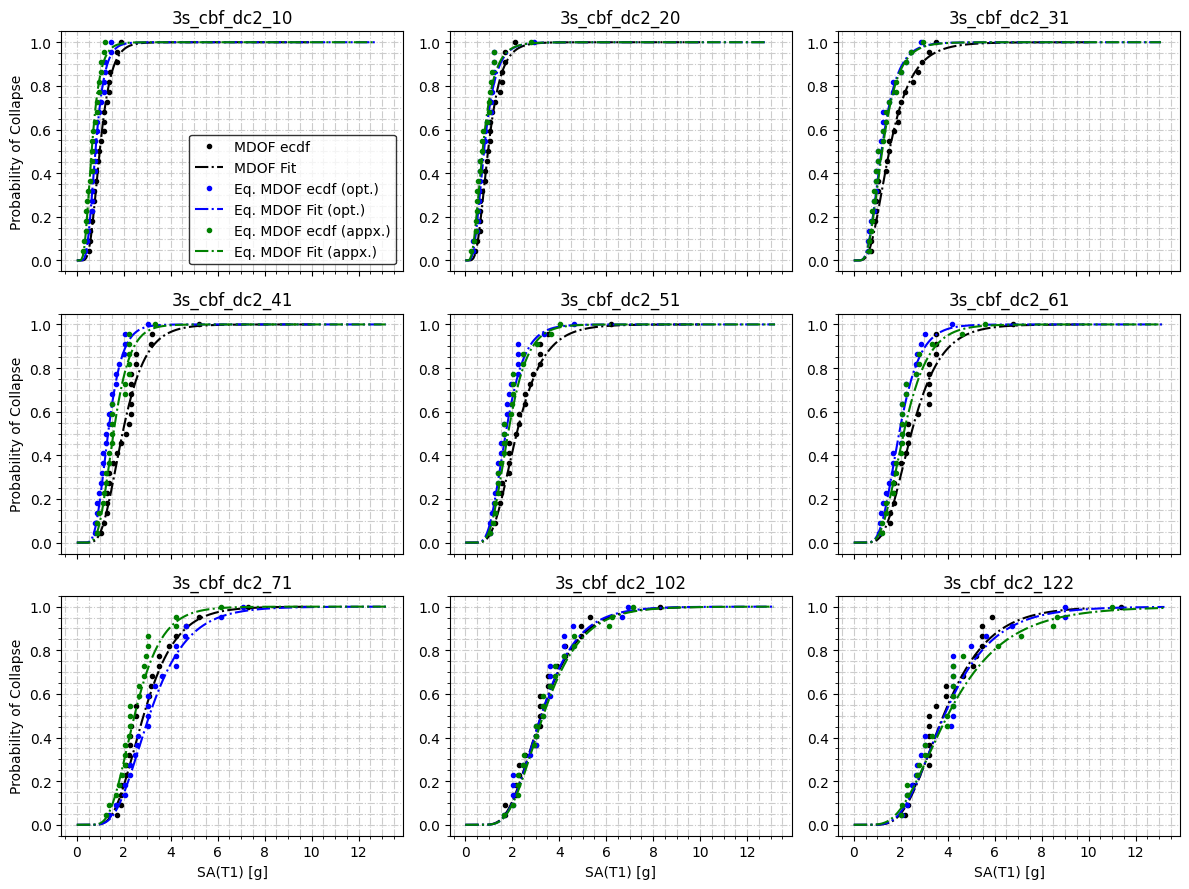

In [51]:
total_n = len(configs_3s)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True)

g = 9810        # mm/s^2
sdof_fragilities = {}
appx_sdof_fragilities = {}
mdof_fragilities = {}

for ax, b in zip(axs.flatten(), buildings):
    sdof_folder = ROOT / f"{b}_sdof" / "ida_femap695"
    appx_sdof_folder = ROOT / f"{b}_appx_sdof" / "ida_femap695"
    mdof_folder = ROOT / b / "ida_femap695"
    
    # load collapse fragility
    with open(sdof_folder / "collapse_fragility.json", "r") as file:
        sdof_cf_data = json.load(file) 

    sdof_fragilities[b] = sdof_cf_data
    x = np.linspace(0.01, 10 * g, 200) # in mm/s²
    sdof_y = lognorm.cdf(x, s=sdof_cf_data["dispersion"], scale=sdof_cf_data["median"])
    sdof_fragilities[b]["fc"] = np.column_stack([x, sdof_y])

    with open(appx_sdof_folder / "collapse_fragility.json", "r") as file:
        appx_sdof_cf_data = json.load(file) 

    appx_sdof_fragilities[b] = appx_sdof_cf_data
    appx_sdof_y = lognorm.cdf(x, s=appx_sdof_cf_data["dispersion"], scale=appx_sdof_cf_data["median"])
    appx_sdof_fragilities[b]["fc"] = np.column_stack([x, appx_sdof_y])

    try:
        with open(mdof_folder / "collapse_fragility.json", "r") as file:
            mdof_cf_data = json.load(file) 

        mdof_fragilities[b] = mdof_cf_data
        mdof_y = lognorm.cdf(x, s=mdof_cf_data["dispersion"], scale=mdof_cf_data["median"])
        mdof_fragilities[b]["fc"] = np.column_stack([x, mdof_y])

        # plot collapse fragility
        ax.plot(np.array(mdof_cf_data["efc"][0]) / g, mdof_cf_data["efc"][1], marker=".", ls="", color="k", label="MDOF ecdf")
        ax.plot(x / g, mdof_y, ls="-.", color="k", label="MDOF Fit")
    except FileNotFoundError:
        continue

    ax.plot(np.array(sdof_cf_data["efc"][0]) * gammas[b] / g, sdof_cf_data["efc"][1], marker=".", ls="", color="b", label="Eq. MDOF ecdf (opt.)")
    ax.plot(x * gammas[b] / g, sdof_y, ls="-.", color="b", label="Eq. MDOF Fit (opt.)")
    
    ax.plot(np.array(appx_sdof_cf_data["efc"][0]) * gammas[b] / g, appx_sdof_cf_data["efc"][1], marker=".", ls="", color="g", label="Eq. MDOF ecdf (appx.)")
    ax.plot(x * gammas[b] / g, appx_sdof_y, ls="-.", color="g", label="Eq. MDOF Fit (appx.)")

    ax.grid(which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.set_title(b)   

    for ax in axs.flatten()[-3:]:
        ax.set_xlabel("SA(T1) [g]")

    for ax in axs[:, 0]:
        ax.set_ylabel("Probability of Collapse")

    leg = axs[0, 0].legend()
    frame = leg.get_frame()
    frame.set_edgecolor("k")
    plt.tight_layout()

comparison of dispersion and median values

0.9742145411084113 0.7913386329175014 1.2310969041365825 0.39107251786432023 0.3878927818453931 1.0081974611741924
0.966843121948995 0.7939882750282995 1.2177045333755523 0.44205824992418014 0.4892170046221526 0.903603606881172
1.510375058140333 1.179311103515142 1.280726564549759 0.4981684692179012 0.44098008077136797 1.1296847430081163
1.9440798590881847 1.330444889198977 1.4612253952575667 0.39627264374585197 0.3521633967332211 1.1252522193442083
2.187509350278635 1.7199196613589278 1.2718671688131404 0.412695145249722 0.3634433371772554 1.1355144063308167
2.4461804666095937 1.9297661352101454 1.2676046190142167 0.4012677686210173 0.3572365042518345 1.1232552212473306
2.8398170230692616 3.0859623426707805 0.92023709550892 0.3827402974131854 0.4074947556275904 0.9392520814745696
3.231390225499998 3.226601750366852 1.0014840614068972 0.38588660234753286 0.3722893700712396 1.0365232890578944
3.8150044100474925 3.8503390541428364 0.9908229785485191 0.3959911941415201 0.41709283547165393

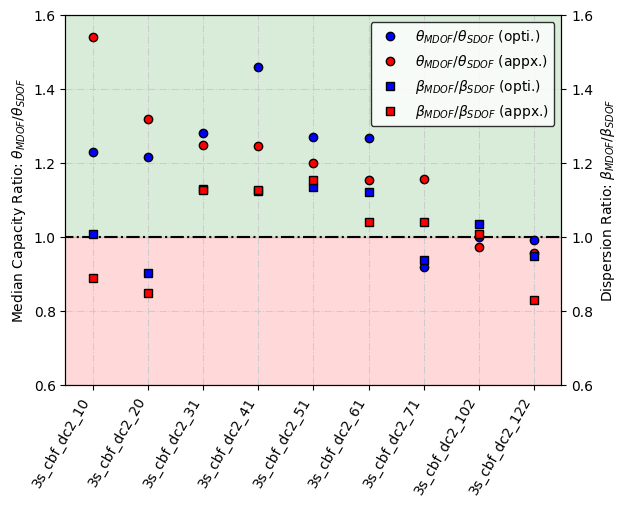

In [52]:
fig, ax = plt.subplots()
ax_twin = ax.twinx()

theta_ratios = []
beta_ratios = []
appx_theta_ratios = []
appx_beta_ratios = []

tick_labels = []

for b in buildings:
    sdof_theta = sdof_fragilities[b]["median"] * gammas[b]
    sdof_beta = sdof_fragilities[b]["dispersion"]

    appx_sdof_theta = appx_sdof_fragilities[b]["median"] * gammas[b]
    appx_sdof_beta = appx_sdof_fragilities[b]["dispersion"]

    try:
        mdof_theta = mdof_fragilities[b]["median"]
        mdof_beta = mdof_fragilities[b]["dispersion"]

        theta_ratios.append(mdof_theta / sdof_theta)
        beta_ratios.append(mdof_beta / sdof_beta)

        appx_theta_ratios.append(mdof_theta / appx_sdof_theta)
        appx_beta_ratios.append(mdof_beta / appx_sdof_beta)
    
    except KeyError:
        continue

    tick_labels.append(b)
    print(mdof_theta/9810, sdof_theta/9810, theta_ratios[-1], mdof_beta, sdof_beta, beta_ratios[-1])

ax.grid(ls="-.", color="0.8")
ax.hlines(1.0, -1, 9, color="k", ls="-.")
ax.plot(theta_ratios, ls="", marker="o", mec="k", mfc="b", label=r"$\theta_{MDOF}$/$\theta_{SDOF}$ (opti.)")
ax_twin.plot(beta_ratios, ls="", marker="s", mec="k", mfc="b", label=r"$\beta_{MDOF}$/$\beta_{SDOF}$ (opti.)")
ax.plot(appx_theta_ratios, ls="", marker="o", mec="k", mfc="r", label=r"$\theta_{MDOF}$/$\theta_{SDOF}$ (appx.)")
ax_twin.plot(appx_beta_ratios, ls="", marker="s", mec="k", mfc="r", label=r"$\beta_{MDOF}$/$\beta_{SDOF}$ (appx.)")
ax.fill_between([-1, 9], 1.6, 1.0, color="green", alpha=0.15)
ax.fill_between([-1, 9], 0.6, 1.0, color="red", alpha=0.15)

ax.set_xlim(-0.5, 8.5)
ax.set_ylim(0.6, 1.6)
ax.set_ylabel(r"Median Capacity Ratio: $\theta_{MDOF}$/$\theta_{SDOF}$")
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, rotation=60, ha="right")


ax_twin.set_ylim(0.6, 1.6)
ax_twin.set_ylabel(r"Dispersion Ratio: $\beta_{MDOF}$/$\beta_{SDOF}$")

legend_handles = ax.get_legend_handles_labels()[0] + ax_twin.get_legend_handles_labels()[0]
legend_labels = ax.get_legend_handles_labels()[1] + ax_twin.get_legend_handles_labels()[1]
leg = ax.legend(legend_handles, legend_labels)
frame = leg.get_frame()
frame.set_edgecolor("k")



### 2.7.2 Median IDA Curves

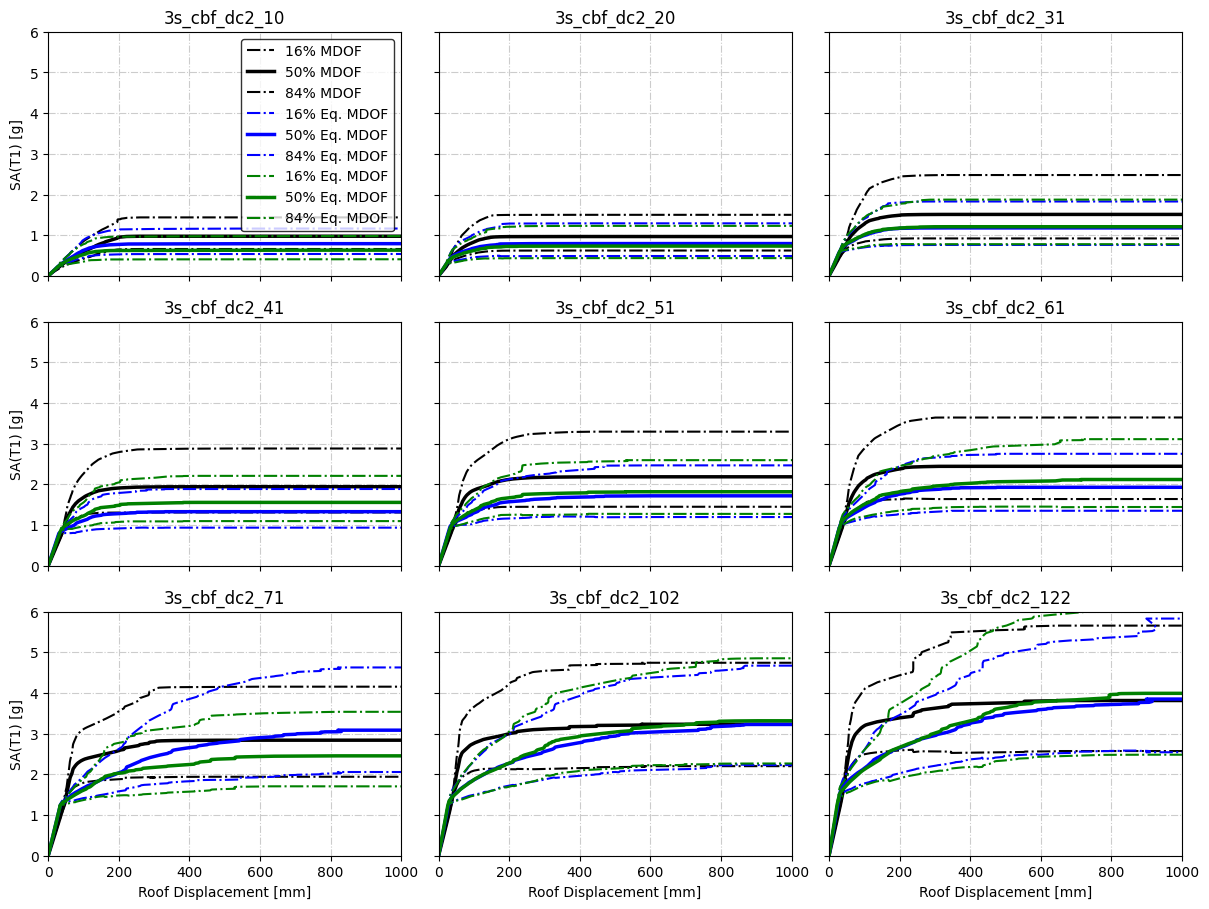

In [53]:
total_n = len(configs_3s)
n_rows = int(round(total_n / 3, 0))
n_cols = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3, ), sharex=True, sharey=True)

g = 9810        # mm/s^2
height = 10500  # mm
x_max = 1000

for ax, b in zip(axs.flatten(), buildings):
    sdof_folder = ROOT / f"{b}_sdof" / "ida_femap695" /"roof_displacement/ida_splines"
    appx_sdof_folder = ROOT / f"{b}_appx_sdof" / "ida_femap695" /"roof_displacement/ida_splines"
    mdof_folder = ROOT / b / "ida_femap695" /"roof_drift/ida_splines"
    
    # load the fractile splines
    sdof_pc16 = np.loadtxt(sdof_folder / "fractile_16pc_ida_spline.csv", delimiter=",")
    sdof_pc50 = np.loadtxt(sdof_folder / "fractile_50pc_ida_spline.csv", delimiter=",")
    sdof_pc84 = np.loadtxt(sdof_folder / "fractile_84pc_ida_spline.csv", delimiter=",")

    sdof_pc16 = np.concatenate([sdof_pc16, [[x_max, sdof_pc16[-1, 1]]]])
    sdof_pc50 = np.concatenate([sdof_pc50, [[x_max, sdof_pc50[-1, 1]]]])
    sdof_pc84 = np.concatenate([sdof_pc84, [[x_max, sdof_pc84[-1, 1]]]])

    appx_sdof_pc16 = np.loadtxt(appx_sdof_folder / "fractile_16pc_ida_spline.csv", delimiter=",")
    appx_sdof_pc50 = np.loadtxt(appx_sdof_folder / "fractile_50pc_ida_spline.csv", delimiter=",")
    appx_sdof_pc84 = np.loadtxt(appx_sdof_folder / "fractile_84pc_ida_spline.csv", delimiter=",")

    appx_sdof_pc16 = np.concatenate([appx_sdof_pc16, [[x_max, appx_sdof_pc16[-1, 1]]]])
    appx_sdof_pc50 = np.concatenate([appx_sdof_pc50, [[x_max, appx_sdof_pc50[-1, 1]]]])
    appx_sdof_pc84 = np.concatenate([appx_sdof_pc84, [[x_max, appx_sdof_pc84[-1, 1]]]])

    try:
        mdof_pc16 = np.loadtxt(mdof_folder / "fractile_16pc_ida_spline.csv", delimiter=",")
        mdof_pc50 = np.loadtxt(mdof_folder / "fractile_50pc_ida_spline.csv", delimiter=",")
        mdof_pc84 = np.loadtxt(mdof_folder / "fractile_84pc_ida_spline.csv", delimiter=",")

        mdof_pc16 = np.concatenate([mdof_pc16, [[x_max / height, mdof_pc16[-1, 1]]]])
        mdof_pc50 = np.concatenate([mdof_pc50, [[x_max / height, mdof_pc50[-1, 1]]]])
        mdof_pc84 = np.concatenate([mdof_pc84, [[x_max / height, mdof_pc84[-1, 1]]]])
    except FileNotFoundError:
         continue

    ax.plot(mdof_pc16[:, 0] * height, mdof_pc16[:, 1] / g, ls="-.", color="k", label=r"16% MDOF", alpha=1.0, lw=1.5)
    ax.plot(mdof_pc50[:, 0] * height, mdof_pc50[:, 1] / g, ls="-", color="k", label=r"50% MDOF", lw=2.5)
    ax.plot(mdof_pc84[:, 0] * height, mdof_pc84[:, 1] / g, ls="-.", color="k", label=r"84% MDOF", alpha=1.0, lw=1.5)
    ax.plot(sdof_pc16[:, 0] * gammas[b], sdof_pc16[:, 1] * gammas[b] / g, ls="-.", color="b", label=r"16% Eq. MDOF", alpha=1, lw=1.5)
    ax.plot(sdof_pc50[:, 0] * gammas[b], sdof_pc50[:, 1] * gammas[b] / g, ls="-", color="b", label=r"50% Eq. MDOF", lw=2.5)
    ax.plot(sdof_pc84[:, 0] * gammas[b], sdof_pc84[:, 1] * gammas[b] / g, ls="-.", color="b", label=r"84% Eq. MDOF", alpha=1, lw=1.5)
    ax.plot(appx_sdof_pc16[:, 0] * gammas[b], appx_sdof_pc16[:, 1] * gammas[b] / g, ls="-.", color="g", label=r"16% Eq. MDOF", alpha=1, lw=1.5)
    ax.plot(appx_sdof_pc50[:, 0] * gammas[b], appx_sdof_pc50[:, 1] * gammas[b] / g, ls="-", color="g", label=r"50% Eq. MDOF", lw=2.5)
    ax.plot(appx_sdof_pc84[:, 0] * gammas[b], appx_sdof_pc84[:, 1] * gammas[b] / g, ls="-.", color="g", label=r"84% Eq. MDOF", alpha=1, lw=1.5)
    
    
    
    ax.grid(which="major", ls="-.", color="0.8")
    ax.set_title(b)
    # ax.minorticks_on()

ax.set_xlim(0, x_max)
ax.set_ylim(0, 6)
leg = axs.flatten()[0].legend()
frame = leg.get_frame()
frame.set_edgecolor("k")
plt.tight_layout()

for ax in axs.flatten()[-3:]:
        ax.set_xlabel("Roof Displacement [mm]")

for ax in axs[:, 0]:
    ax.set_ylabel("SA(T1) [g]")

## 2.8 Combined Backbones

In [54]:
(bdata_df["seismic_mass"] * 9.81)

name
3s_cbf_dc2_10     3061800.0
3s_cbf_dc2_20     3061800.0
3s_cbf_dc2_31     3061800.0
3s_cbf_dc2_41     3061800.0
3s_cbf_dc2_51     3061800.0
3s_cbf_dc2_61     3061800.0
3s_cbf_dc2_71     3061800.0
3s_cbf_dc2_102    3061800.0
3s_cbf_dc2_122    3061800.0
5s_cbf_dc2_10     5178600.0
5s_cbf_dc2_20     5178600.0
5s_cbf_dc2_31     5178600.0
5s_cbf_dc2_41     5178600.0
5s_cbf_dc2_51     5178600.0
5s_cbf_dc2_61     5178600.0
5s_cbf_dc2_71     5178600.0
5s_cbf_dc2_102    5178600.0
5s_cbf_dc2_122    5178600.0
7s_cbf_dc2_10     7295400.0
7s_cbf_dc2_20     7295400.0
7s_cbf_dc2_31     7295400.0
7s_cbf_dc2_41     7295400.0
7s_cbf_dc2_51     7295400.0
7s_cbf_dc2_61     7295400.0
7s_cbf_dc2_71     7295400.0
Name: seismic_mass, dtype: float64

In [55]:
def total_backbone(Vb_coeff, Wt, hi, aspect):
    br_bb = get_approximate_br_backbone(Vb_coeff, Wt, hi, aspect)
    ss_bb = get_approximate_ss_backbone(Vb_coeff, Wt, hi)

    all_x = np.unique(np.concatenate([br_bb[:, 0], ss_bb[:, 0]]))
    all_x.sort()
    br_y = np.interp(all_x, br_bb[:, 0], br_bb[:, 1])
    ss_y = np.interp(all_x, ss_bb[:, 0], ss_bb[:, 1])
    total = br_y + ss_y

    return np.column_stack([all_x, total])

### 2.8.1 Variation with Vb

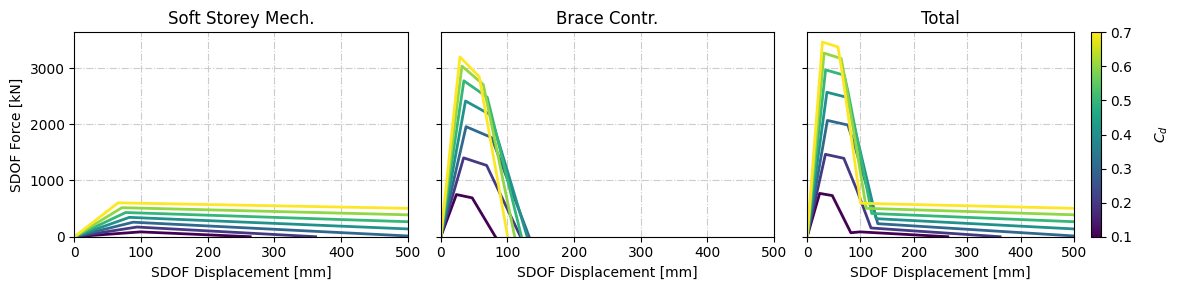

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(12,3), sharey=True)

Wt = 3060000
hi = 3500
aspect = 0.5
vbs = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=vbs.min(), vmax=vbs.max())

for vb in vbs:
    bb_br = get_approximate_br_backbone(vb, Wt, hi, aspect)
    bb_ss = get_approximate_ss_backbone(vb, Wt, hi)
    bb_t = total_backbone(vb, Wt, hi, aspect)
    color = cmap(norm(vb))

    axs[0].plot(bb_ss[:, 0], bb_ss[:, 1] / 1000, color=color, lw=2)
    axs[1].plot(bb_br[:, 0], bb_br[:, 1] / 1000, color=color, lw=2)
    axs[2].plot(bb_t[:, 0], bb_t[:, 1] / 1000, color=color, lw=2)

for ax in axs:
    ax.set_xlabel("SDOF Displacement [mm]")
    ax.set_xlim(0, 500)
    ax.grid(ls="-.", color="0.8")

axs[0].set_ylabel("SDOF Force [kN]")
axs[0].set_title("Soft Storey Mech.")
axs[1].set_title("Brace Contr.")
axs[2].set_title("Total")
ax.set_ylim(0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axs[2])
cbar.set_label("$C_d$", rotation=90, labelpad=15)

plt.tight_layout()

### 2.8.2 Variation with Aspect ratio

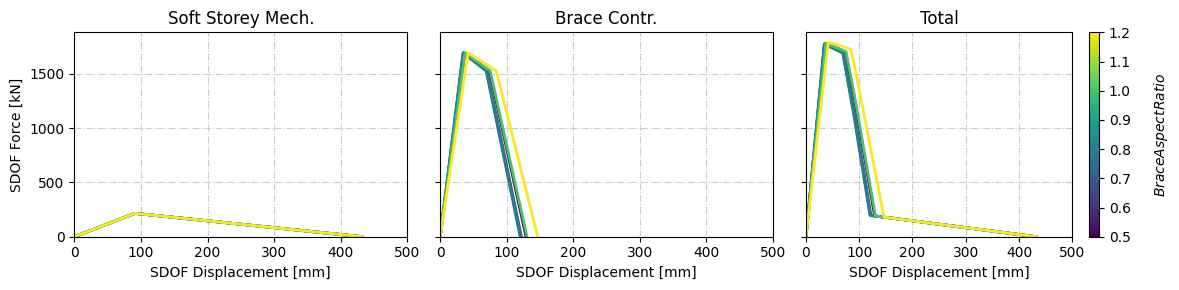

In [57]:
fig, axs = plt.subplots(1, 3, figsize=(12,3), sharey=True)

Wt = 3060000
hi = 3500
vb = 0.25
aspects = np.array([0.5, 0.6, 0.75, 0.8, 1.0, 1.2])

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=aspects.min(), vmax=aspects.max())

for aspect in aspects:
    bb_br = get_approximate_br_backbone(vb, Wt, hi, aspect)
    bb_ss = get_approximate_ss_backbone(vb, Wt, hi)
    bb_t = total_backbone(vb, Wt, hi, aspect)
    color = cmap(norm(aspect))

    axs[0].plot(bb_ss[:, 0], bb_ss[:, 1] / 1000, color=color, lw=2)
    axs[1].plot(bb_br[:, 0], bb_br[:, 1] / 1000, color=color, lw=2)
    axs[2].plot(bb_t[:, 0], bb_t[:, 1] / 1000, color=color, lw=2)

for ax in axs:
    ax.set_xlabel("SDOF Displacement [mm]")
    ax.set_xlim(0, 500)
    ax.grid(ls="-.", color="0.8")

axs[0].set_ylabel("SDOF Force [kN]")
axs[0].set_title("Soft Storey Mech.")
axs[1].set_title("Brace Contr.")
axs[2].set_title("Total")
ax.set_ylim(0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axs[2])
cbar.set_label("$Brace Aspect Ratio$", rotation=90, labelpad=15)

plt.tight_layout()